# OMIE Data Validation & Structural Statistics

**Purpose:** Exploratory only — not thesis output.

1. Spot-validate prices against the OMIE website
2. Spot-validate aggregate supply/demand curves
3. Structural statistics around the MTU15 reform

Reform dates:
- Intraday auctions + continuous: **2025-03-19**
- Day-ahead market: **2025-10-01**

In [1]:
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

PROJECT_ROOT = Path("../").resolve()

MARGINALPDBC  = PROJECT_ROOT / "data/processed/omie/mercado_diario/precios/marginalpdbc_all.parquet"
MARGINALPIBC  = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_subastas/precios/marginalpibc_all.parquet"
CURVA_PBC_DIR = PROJECT_ROOT / "data/processed/omie/mercado_diario/curvas/curva_pbc"

# Structural breaks (all dates = first day of new regime)
IDA_REFORM       = pd.Timestamp("2024-06-14")  # 6 local MIBEL sessions → 3 European IDA sessions
INTRADAY_REFORM  = pd.Timestamp("2025-03-19")  # MTU60 → MTU15 for intraday auctions + continuous
DAY_AHEAD_REFORM = pd.Timestamp("2025-10-01")  # MTU60 → MTU15 for day-ahead market

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
## Section 1 — Price spot-validation

Data: `marginalpdbc_all.parquet` — the day-ahead uniform-price auction (OMIE, Iberian peninsula).

**Market-clearing condition.** The auction clears at the unique marginal price $p^*_t$ (EUR/MWh) for delivery period $t$, defined as the intersection of the aggregate supply and demand step functions:

$$p^*_t = \inf\bigl\{p \geq 0 : Q^S_t(p) \geq Q^D_t(p)\bigr\}$$

When the Portugal–Spain interconnection is not binding, a single Iberian price clears ($p^*_{\text{ES},t} = p^*_{\text{PT},t}$). When the interconnection is congested, the two zones decouple.

Compare with: https://www.omie.es/es/market-results/daily/daily-market/day-ahead-price


In [2]:
CHECK_DATE = "2026-04-10"  # <-- change to any date to spot-check

df = pd.read_parquet(MARGINALPDBC)
day = df[df["date"] == CHECK_DATE].sort_values("period")[["period", "price_es_eur_mwh", "price_pt_eur_mwh"]]

print(f"Date: {CHECK_DATE}  |  MTU: {df.loc[df['date']==CHECK_DATE, 'mtu_minutes'].iloc[0]} min  |  Periods: {len(day)}")
print(day.to_string(index=False))

Date: 2026-04-10  |  MTU: 15 min  |  Periods: 96
 period  price_es_eur_mwh  price_pt_eur_mwh
      1             54.70             54.70
      2             51.20             51.20
      3             47.12             47.12
      4             38.90             38.90
      5             39.90             39.90
      6             38.90             38.90
      7             39.64             39.64
      8             39.51             39.51
      9             39.89             39.89
     10             39.77             39.77
     11             39.77             39.77
     12             39.77             39.77
     13             39.77             39.77
     14             39.77             39.77
     15             39.77             39.77
     16             39.89             39.89
     17             39.77             39.77
     18             39.89             39.89
     19             39.89             39.89
     20             39.90             39.90
     21             39.89  

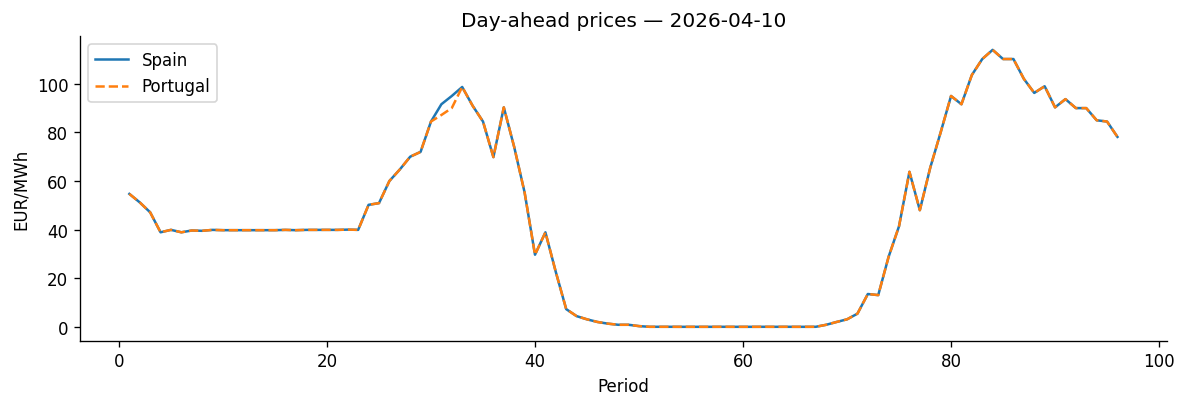

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(day["period"], day["price_es_eur_mwh"], label="Spain", linewidth=1.5)
ax.plot(day["period"], day["price_pt_eur_mwh"], label="Portugal", linewidth=1.5, linestyle="--")
ax.set_xlabel("Period")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Day-ahead prices — {CHECK_DATE}")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 2 — Aggregate curve spot-validation

Data: `curva_pbc` — OMIE publishes the full aggregate supply and demand step functions for each period.

**Step-function representation.** The aggregate supply curve is:

$$Q^S_t(p) = \sum_{i \in \mathcal{I}} q_{i,t}\,\mathbf{1}[c_{i,t} \leq p]$$

where $q_{i,t}$ is the quantity offered by unit $i$ in period $t$ at marginal cost (bid price) $c_{i,t}$. The demand curve $Q^D_t(p)$ is the mirror: offered purchase quantities sorted by willingness to pay. The equilibrium price $p^*_t$ is where the two curves intersect.

Compare with: https://www.omie.es/es/market-results/daily/daily-market/aggragate-suply-curves


In [4]:
CHECK_DATE_CURVE = "2026-04-08"  # <-- change to any date
CHECK_PERIOD     = 20            # <-- period number (1-24 for MTU60, 1-96 for MTU15)

# country='MI' = Iberian market aggregate curve (what OMIE shows on the website).
# country='ES'/'PT' only appear post-reform for periods with market splitting (price separation).
glob = str(CURVA_PBC_DIR / "*.parquet")
df_curve = duckdb.query(
    f"SELECT * FROM read_parquet('{glob}', union_by_name=true) "
    f"WHERE date='{CHECK_DATE_CURVE}' AND period_num={CHECK_PERIOD} AND country='MI'"
).df()

print(f"Rows for date={CHECK_DATE_CURVE}, period={CHECK_PERIOD}, country=MI: {len(df_curve)}")
print(df_curve[["offer_type", "curve_type", "power_mw", "price_eur_mwh"]].head(10))

Rows for date=2026-04-08, period=20, country=MI: 3949
  offer_type curve_type  power_mw  price_eur_mwh
0          C          O     120.2         1500.0
1          C          O     329.0         1500.0
2          C          O      19.2         1500.0
3          C          O    1612.8          501.0
4          C          O      14.7          501.0
5          C          O     210.4          501.0
6          C          O      43.3          500.0
7          C          O     230.3          500.0
8          C          O     143.2          500.0
9          C          O     272.4          500.0


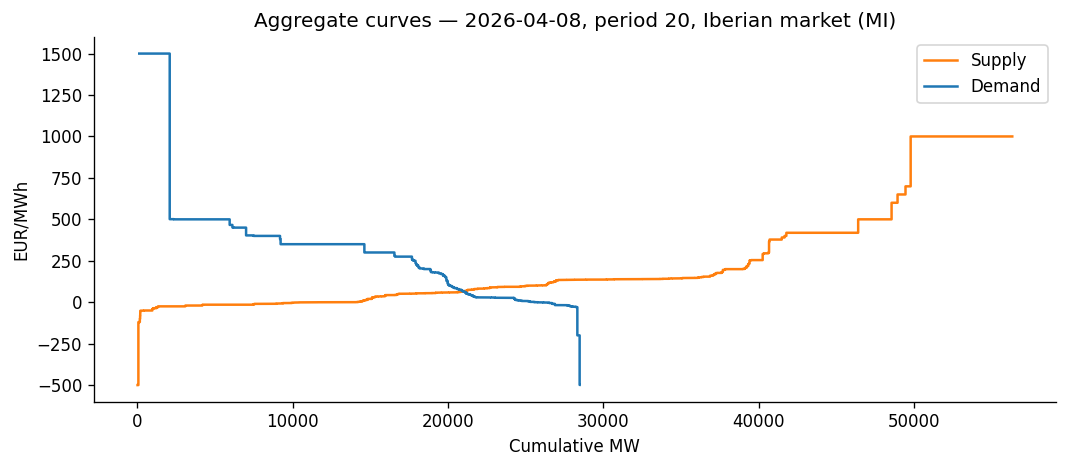

In [5]:
def build_staircase(df_steps, price_col="price_eur_mwh", power_col="power_mw", ascending=True):
    """Sort steps by price and compute cumulative MW."""
    s = df_steps.sort_values(price_col, ascending=ascending).copy()
    s["cum_mw"] = s[power_col].cumsum()
    return s

supply = build_staircase(
    df_curve[(df_curve["offer_type"] == "V") & (df_curve["curve_type"] == "O")],
    ascending=True,
)
demand = build_staircase(
    df_curve[(df_curve["offer_type"] == "C") & (df_curve["curve_type"] == "O")],
    ascending=False,  # demand curve: high prices first
)

fig, ax = plt.subplots(figsize=(9, 4))
if not supply.empty:
    ax.step(supply["cum_mw"], supply["price_eur_mwh"], where="post", label="Supply", color="tab:orange")
if not demand.empty:
    ax.step(demand["cum_mw"], demand["price_eur_mwh"], where="post", label="Demand", color="tab:blue")
ax.set_xlabel("Cumulative MW")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Aggregate curves — {CHECK_DATE_CURVE}, period {CHECK_PERIOD}, Iberian market (MI)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — Structural statistics

> **Note on price levels:** Price changes reflect renewable growth, regulation, and the MTU15 reform simultaneously. Price-level comparisons are not clean reform signals. Focus on *structural* metrics.

**Reform regimes** for the day-ahead market:

| Regime | Period | MTU $\delta$ | Periods/day |
|---|---|---|---|
| Pre-reform | before 2025-10-01 | 60 min | 24 |
| Post-reform | from 2025-10-01 | 15 min | 96 |

The key structural question is whether the finer $\delta = 15$ min resolution reveals price variation that was previously averaged away within each hour.


In [6]:
# Load full price dataset once
df_prices = pd.read_parquet(MARGINALPDBC)
df_prices["date"] = pd.to_datetime(df_prices["date"])
print(f"marginalpdbc: {len(df_prices):,} rows, {df_prices['date'].min().date()} → {df_prices['date'].max().date()}")

marginalpdbc: 86,447 rows, 2018-01-01 → 2026-04-11


### 3a. Within-day price profile

**Within-day price profile.** For regime $r \in \{\text{pre}, \text{post}\}$, the mean price at period $\pi$ is:

$$\bar{p}^r_\pi = \frac{1}{|T_r|} \sum_{t \in T_r} p^*_{t,\pi}$$

where $T_r$ is the set of trading days in regime $r$. Pre-reform, $\pi \in \{1,\ldots,24\}$ (hours). Post-reform, $\pi \in \{1,\ldots,96\}$ (quarter-hours). The profile reveals the daily demand cycle — ramps, peak, and off-peak — at the resolution available in each regime.


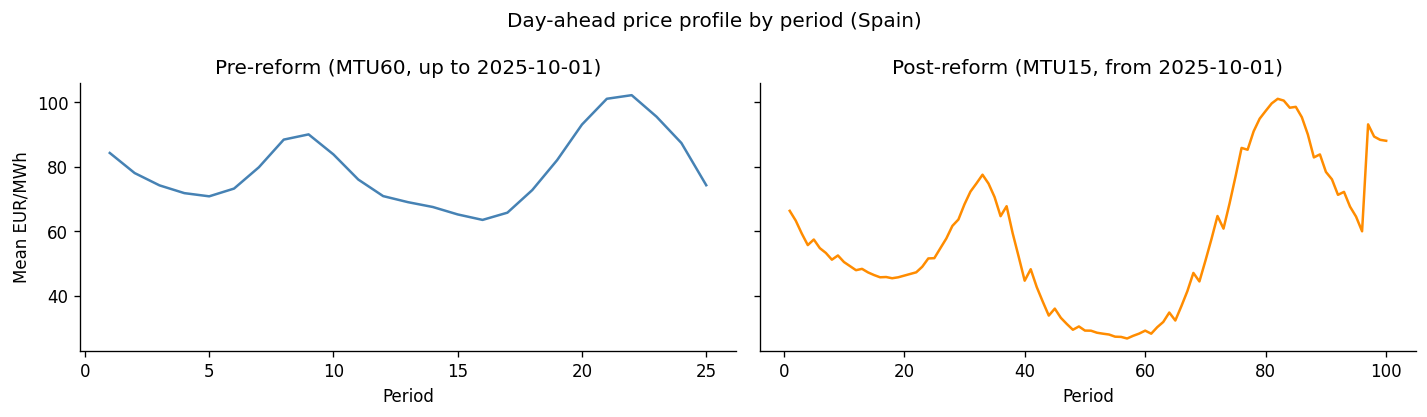

In [7]:
pre  = df_prices[df_prices["date"] < DAY_AHEAD_REFORM]
post = df_prices[df_prices["date"] >= DAY_AHEAD_REFORM]

pre_profile  = pre.groupby("period")["price_es_eur_mwh"].mean()
post_profile = post.groupby("period")["price_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {DAY_AHEAD_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15, from {DAY_AHEAD_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Day-ahead price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

### 3b. Intra-hour price dispersion — core MTU15 metric

**Intra-hour dispersion.** Post-reform only. Each hour $h \in \{1,\ldots,24\}$ contains four quarter-hour periods $Q_h = \{4(h-1)+1,\ldots,4h\}$. The intra-hour price standard deviation for day $t$ and hour $h$ is:

$$\sigma_{t,h} = \sqrt{\frac{1}{4}\sum_{\pi \in Q_h}\bigl(p^*_{t,\pi} - \bar{p}_{t,h}\bigr)^2}, \quad \bar{p}_{t,h} = \frac{1}{4}\sum_{\pi \in Q_h} p^*_{t,\pi}$$

The reported metric is the mean across days: $\bar{\sigma}_h = \frac{1}{|T_{\text{post}}|}\sum_t \sigma_{t,h}$. Under hourly trading this variation is invisible — the reform reveals it.


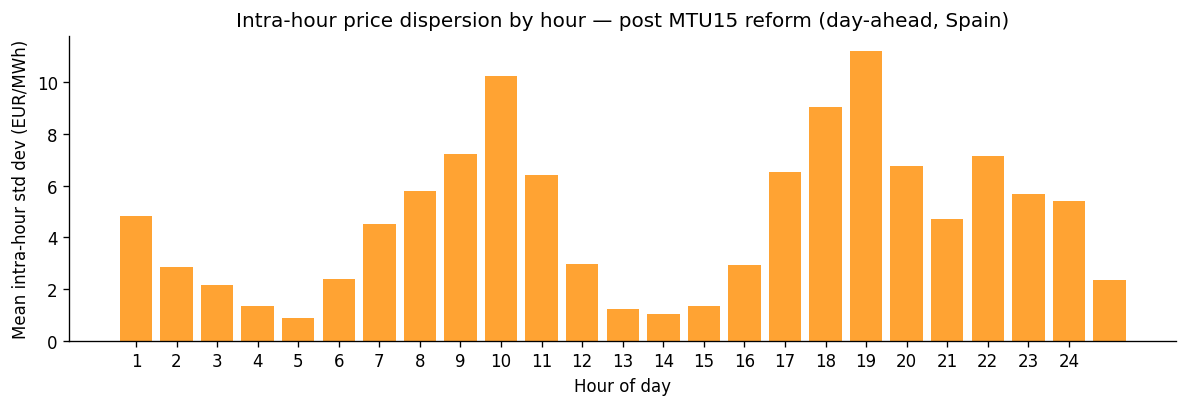

Overall mean intra-hour std dev: 4.68 EUR/MWh
Max (hour 19): 11.23 EUR/MWh


In [8]:
post_mtu15 = df_prices[(df_prices["date"] >= DAY_AHEAD_REFORM) & (df_prices["mtu_minutes"] == 15)].copy()
# Map period (1-96) to hour-of-day (1-24)
post_mtu15["hour"] = ((post_mtu15["period"] - 1) // 4) + 1

# Std dev of 4 quarter-hour prices within each (date, hour)
intra_hour_std = (
    post_mtu15.groupby(["date", "hour"])["price_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_es_eur_mwh"]
    .mean()  # average across days
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std.index, intra_hour_std.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (day-ahead, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std.idxmax()}): {intra_hour_std.max():.2f} EUR/MWh")

### 3c. Monthly price level

Monthly mean price $\bar{p}_m = \frac{1}{|T_m|}\sum_{t \in T_m}\frac{1}{|\Pi_t|}\sum_\pi p^*_{t,\pi}$, where $T_m$ are days in month $m$ and $\Pi_t$ are delivery periods of day $t$.

Price level context only — **not a clean reform signal**. Renewables penetration, gas prices, and hydro conditions all move simultaneously. The reform date lines are shown for reference.


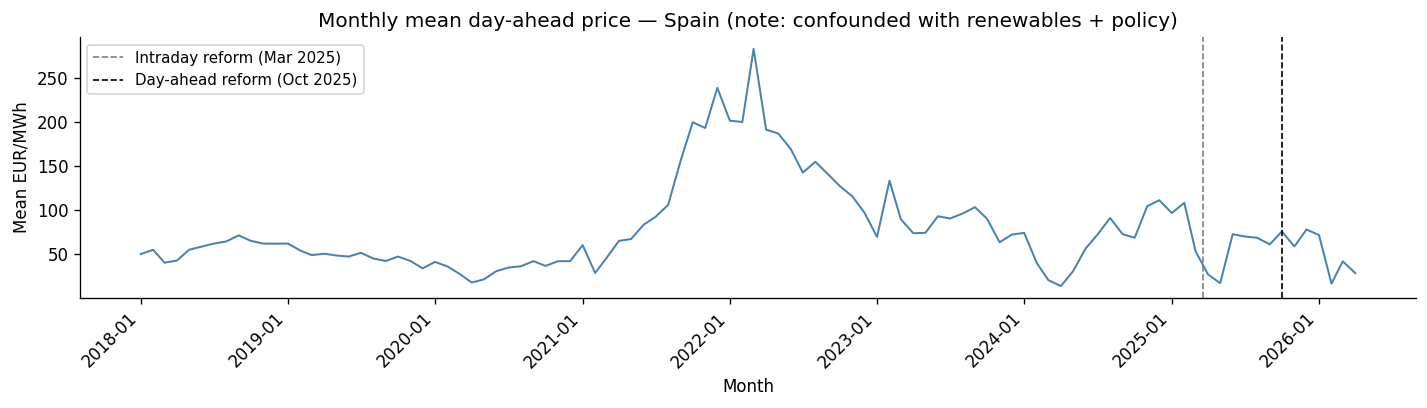

In [9]:
monthly = (
    df_prices.groupby(df_prices["date"].dt.to_period("M"))["price_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly["date"] = monthly["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly["date"], monthly["price_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM,  color="gray",   linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.axvline(DAY_AHEAD_REFORM, color="black",  linestyle="--", linewidth=1, label="Day-ahead reform (Oct 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean day-ahead price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3d. Intraday auction prices across regimes

Three regimes in `marginalpibc`:

| Regime | Period | Sessions | MTU $\delta$ |
|---|---|---|---|
| Pre-IDA | before 2024-06-14 | 6 (MIBEL) | 60 min |
| IDA MTU60 | 2024-06-14 – 2025-03-18 | 3 (IDA1–3) | 60 min |
| IDA MTU15 | from 2025-03-19 | 3 (IDA1–3) | 15 min |

**Cross-session convergence.** If intraday trading efficiently incorporates new information across sessions, prices should converge over the day. The mean cross-session standard deviation is:

$$\bar{\sigma}^{\text{cross}} = \frac{1}{|T_r|} \sum_{t \in T_r} \operatorname{std}_{s}\bigl(\bar{p}_{t,s}\bigr)$$

where $\bar{p}_{t,s}$ is the mean price across all periods in session $s$ on day $t$. Note: IDA3 covers only afternoon delivery (D+12h–24h), so some days legitimately have 2 sessions.


── Intraday reform (MTU15 intraday auctions) (reform: 2025-03-19) ──
  Before (2025-02-19 → 2025-03-18): mean=78.82, median=79.18, std=38.91 EUR/MWh  (n=28 days)
  After  (2025-03-19 → 2025-04-18): mean=26.33, median=14.00, std=34.92 EUR/MWh  (n=31 days)
  Change: -66.6%



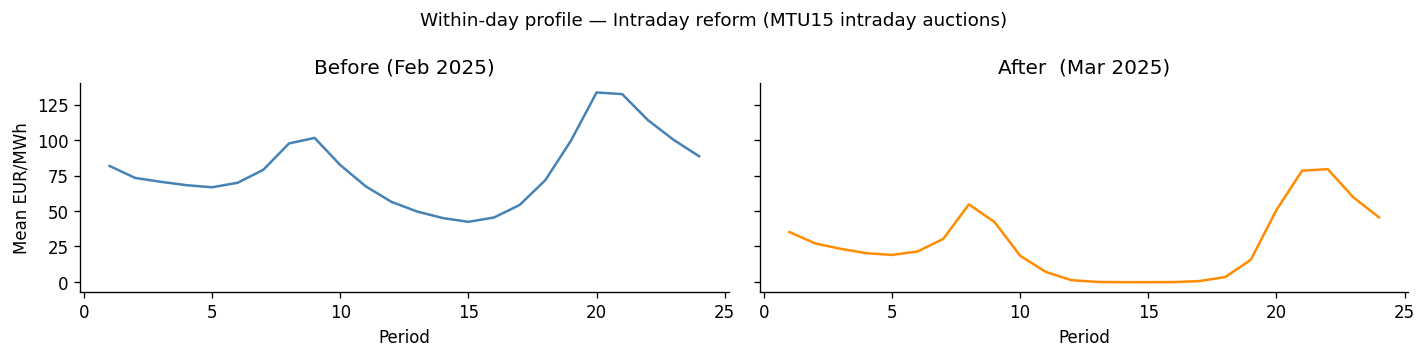

── Day-ahead reform (MTU15 day-ahead) (reform: 2025-10-01) ──
  Before (2025-09-01 → 2025-09-30): mean=61.04, median=66.63, std=42.90 EUR/MWh  (n=30 days)
  After  (2025-10-01 → 2025-10-31): mean=75.75, median=83.61, std=44.55 EUR/MWh  (n=31 days)
  Change: +24.1%



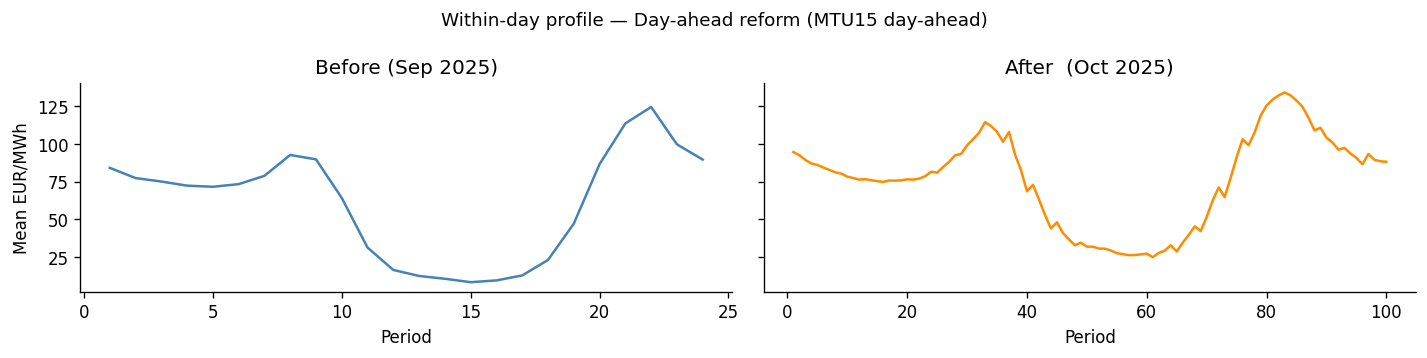

In [10]:
from dateutil.relativedelta import relativedelta

def compare_around_reform(df, reform_date, label, window_months=1):
    before = df[
        (df["date"] >= reform_date - relativedelta(months=window_months)) &
        (df["date"] <  reform_date)
    ]
    after = df[
        (df["date"] >= reform_date) &
        (df["date"] <  reform_date + relativedelta(months=window_months))
    ]
    print(f"── {label} (reform: {reform_date.date()}) ──")
    print(f"  Before ({before['date'].min().date()} → {before['date'].max().date()}): "
          f"mean={before['price_es_eur_mwh'].mean():.2f}, "
          f"median={before['price_es_eur_mwh'].median():.2f}, "
          f"std={before['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={before['date'].nunique()} days)")
    print(f"  After  ({after['date'].min().date()} → {after['date'].max().date()}): "
          f"mean={after['price_es_eur_mwh'].mean():.2f}, "
          f"median={after['price_es_eur_mwh'].median():.2f}, "
          f"std={after['price_es_eur_mwh'].std():.2f} EUR/MWh  (n={after['date'].nunique()} days)")
    pct = (after['price_es_eur_mwh'].mean() - before['price_es_eur_mwh'].mean()) / before['price_es_eur_mwh'].mean() * 100
    print(f"  Change: {pct:+.1f}%\n")

    # Within-day profile comparison (only meaningful if both sides have data)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    for ax, subset, sublabel, color in [
        (axes[0], before, f"Before ({(reform_date - relativedelta(months=window_months)).strftime('%b %Y')})", "steelblue"),
        (axes[1], after,  f"After  ({reform_date.strftime('%b %Y')})", "darkorange"),
    ]:
        profile = subset.groupby("period")["price_es_eur_mwh"].mean()
        ax.plot(profile.index, profile.values, linewidth=1.5, color=color)
        ax.set_title(sublabel)
        ax.set_xlabel("Period")
    axes[0].set_ylabel("Mean EUR/MWh")
    plt.suptitle(f"Within-day profile — {label}", fontsize=11)
    plt.tight_layout()
    plt.show()

compare_around_reform(df_prices, INTRADAY_REFORM,  "Intraday reform (MTU15 intraday auctions)")
compare_around_reform(df_prices, DAY_AHEAD_REFORM, "Day-ahead reform (MTU15 day-ahead)")

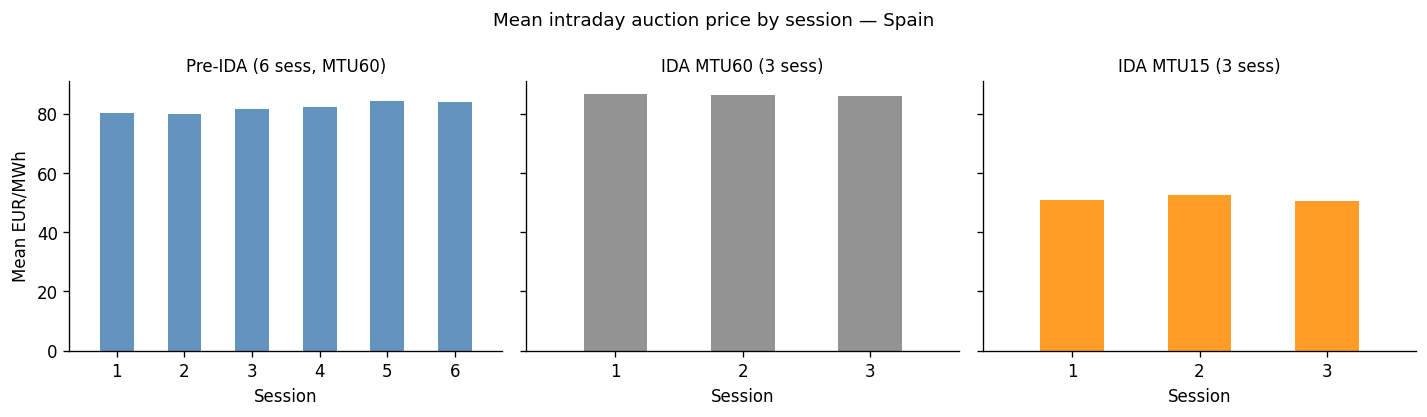

Cross-session price convergence (std dev across sessions per day):
  Pre-IDA (6 sess, MTU60): mean std = 3.48 EUR/MWh  (n = 2351 days with all 6 sessions)
  IDA MTU60 (3 sess): mean std = 6.03 EUR/MWh  (n = 259 days with all 3 sessions)
  IDA MTU15 (3 sess): mean std = 5.62 EUR/MWh  (n = 363 days with all 3 sessions)


In [11]:
IDA_TRANSITION = pd.Timestamp("2024-06-14")  # confirmed from data: last 6-session day was 2024-06-13

df_pibc = pd.read_parquet(MARGINALPIBC)
df_pibc["date"] = pd.to_datetime(df_pibc["date"])

pre_ida   = df_pibc[df_pibc["date"] <  IDA_TRANSITION]
ida_mtu60 = df_pibc[(df_pibc["date"] >= IDA_TRANSITION) & (df_pibc["date"] < INTRADAY_REFORM)]
ida_mtu15 = df_pibc[df_pibc["date"] >= INTRADAY_REFORM]

regimes = [
    ("Pre-IDA (6 sess, MTU60)", pre_ida,   "steelblue",  6),
    ("IDA MTU60 (3 sess)",       ida_mtu60, "gray",       3),
    ("IDA MTU15 (3 sess)",       ida_mtu15, "darkorange", 3),
]

# --- Mean price by session ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (label, subset, color, n_sess) in zip(axes, regimes):
    sess_mean = subset.groupby("session_number")["price_es_eur_mwh"].mean()
    ax.bar(sess_mean.index, sess_mean.values, color=color, alpha=0.85, width=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Session")
    ax.set_xticks(range(1, n_sess + 1))
    ax.set_xlim(0.3, n_sess + 0.7)
axes[0].set_ylabel("Mean EUR/MWh")
plt.suptitle("Mean intraday auction price by session — Spain", fontsize=11)
plt.tight_layout()
plt.show()

# --- Cross-session price convergence (std dev across sessions per day) ---
# Pre-IDA: require all 6 sessions. IDA regimes: require all 3.
# Note: IDA3 only covers afternoon delivery (D 12h–24h), so some days legitimately have 2 sessions.
# Those days are excluded to keep the comparison clean.
print("Cross-session price convergence (std dev across sessions per day):")
for label, subset, color, n_sess in regimes:
    daily_sess = subset.groupby(["date", "session_number"])["price_es_eur_mwh"].mean().reset_index()
    full_days  = daily_sess.groupby("date")["session_number"].count()
    full_days  = full_days[full_days == n_sess].index
    daily_std  = daily_sess[daily_sess["date"].isin(full_days)].groupby("date")["price_es_eur_mwh"].std()
    print(f"  {label}: mean std = {daily_std.mean():.2f} EUR/MWh  (n = {len(daily_std)} days with all {n_sess} sessions)")

---
## Section 4 — Continuous intraday market (`precios_pibcic_ronda`)

Data: `precios_pibcic_ronda_all.parquet` — mean transaction price per round and delivery period in the XBID continuous intraday market.

**Round-price object.** Let $r = 1, 2, \ldots, R_d$ index the trading rounds on day $d$ (approximately 21 rounds/day). For each delivery period $\pi$ and round $r$, OMIE publishes:

$$\bar{p}_{d,r,\pi} = \frac{\sum_k p_k q_k}{\sum_k q_k}$$

the volume-weighted mean transaction price across all trades $k$ executed in round $r$ for delivery period $\pi$ on day $d$. Multiple rounds can trade the same delivery period as the delivery window approaches.

Coverage: **2018-06-13 → 2026-04-09** · 2,857 files · 2,470 MTU60 days + 387 MTU15 days

> **Note:** `precios_pibcic` (the daily aggregate file) has only 2 days downloaded — use `_ronda` instead.


precios_pibcic_ronda: 1,172,276 rows, 2018-06-13 → 2026-04-09
MTU breakdown: {15: 389, 60: 2471} days


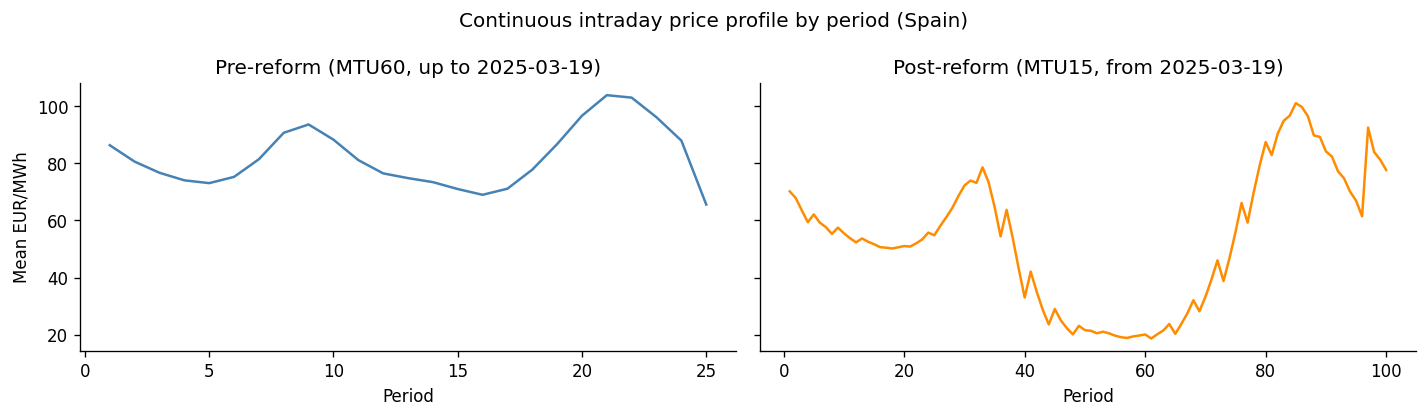

In [12]:
PRECIOS_PIBCIC_RONDA = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/precios/precios_pibcic_ronda_all.parquet"

df_cont = pd.read_parquet(PRECIOS_PIBCIC_RONDA)
df_cont["date"] = pd.to_datetime(df_cont["date"])
print(f"precios_pibcic_ronda: {len(df_cont):,} rows, {df_cont['date'].min().date()} → {df_cont['date'].max().date()}")
print(f"MTU breakdown: {df_cont.groupby('mtu_minutes')['date'].nunique().to_dict()} days")

# Aggregate across rounds: mean price per (date, period). Rounds are intra-day snapshots of the same delivery period.
period_price = df_cont.groupby(["date", "period", "mtu_minutes"])["price_mean_es_eur_mwh"].mean().reset_index()

pre_cont  = period_price[period_price["date"] <  INTRADAY_REFORM]
post_cont = period_price[period_price["date"] >= INTRADAY_REFORM]

pre_profile  = pre_cont.groupby("period")["price_mean_es_eur_mwh"].mean()
post_profile = post_cont.groupby("period")["price_mean_es_eur_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(pre_profile.index,  pre_profile.values,  linewidth=1.5, color="steelblue")
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Mean EUR/MWh")

axes[1].plot(post_profile.index, post_profile.values, linewidth=1.5, color="darkorange")
axes[1].set_title(f"Post-reform (MTU15, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Period")

plt.suptitle("Continuous intraday price profile by period (Spain)", fontsize=12)
plt.tight_layout()
plt.show()

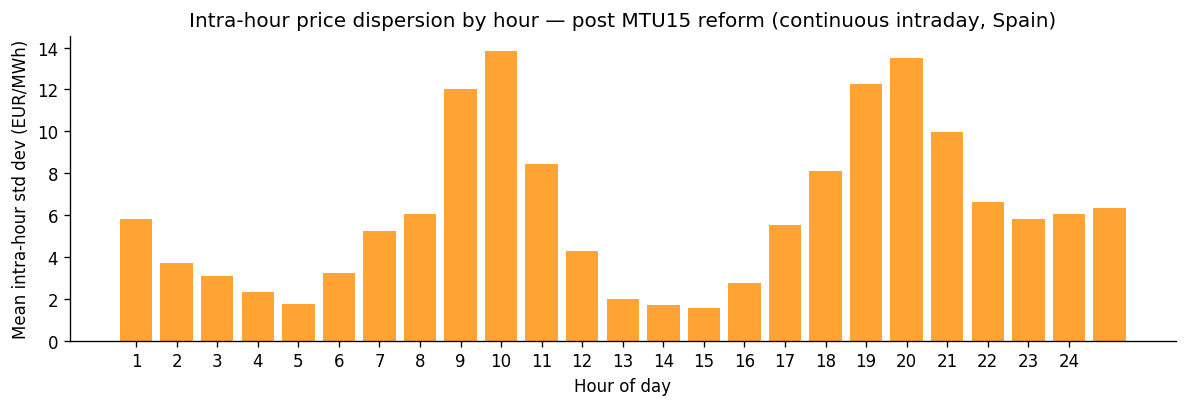

Overall mean intra-hour std dev: 6.08 EUR/MWh
Max (hour 10): 13.86 EUR/MWh


In [13]:
post_mtu15_cont = period_price[(period_price["date"] >= INTRADAY_REFORM) & (period_price["mtu_minutes"] == 15)].copy()
post_mtu15_cont["hour"] = ((post_mtu15_cont["period"] - 1) // 4) + 1

intra_hour_std_cont = (
    post_mtu15_cont.groupby(["date", "hour"])["price_mean_es_eur_mwh"]
    .std()
    .reset_index()
    .groupby("hour")["price_mean_es_eur_mwh"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_cont.index, intra_hour_std_cont.values, color="darkorange", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (EUR/MWh)")
ax.set_title("Intra-hour price dispersion by hour — post MTU15 reform (continuous intraday, Spain)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_cont.mean():.2f} EUR/MWh")
print(f"Max (hour {intra_hour_std_cont.idxmax()}): {intra_hour_std_cont.max():.2f} EUR/MWh")

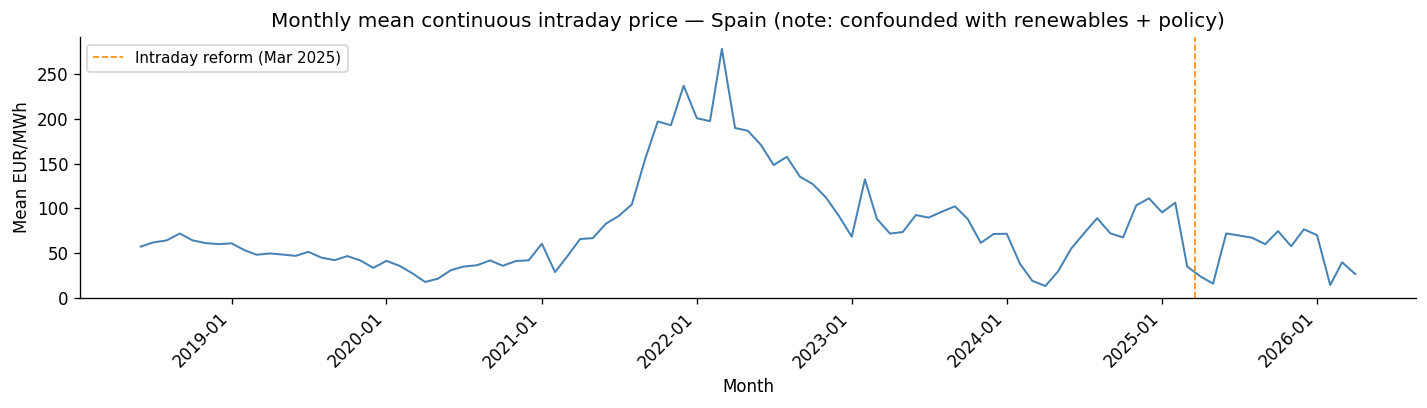

In [14]:
monthly_cont = (
    period_price.groupby(period_price["date"].dt.to_period("M"))["price_mean_es_eur_mwh"]
    .mean()
    .reset_index()
)
monthly_cont["date"] = monthly_cont["date"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(monthly_cont["date"], monthly_cont["price_mean_es_eur_mwh"], linewidth=1.2, color="steelblue")
ax.axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday reform (Mar 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("Monthly mean continuous intraday price — Spain (note: confounded with renewables + policy)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## Section 5 — Continuous intraday matched power (`pibcic`)

Data: `pibcic_all.parquet` — assigned power (MW) per unit, round, and delivery period in the XBID continuous intraday market. Each row is a `(date, round_number, period, unit_code)` triplet with `assigned_power_mw` (positive = buy, negative = sell).

**MWh correction.** Because the number of delivery periods per day increases from 24 (MTU60) to 96 (MTU15), the raw sum of MW is mechanically inflated by a factor of 4 post-reform. The energy-equivalent volume is:

$$E_{d} = \sum_{r,\pi,i} \bigl|m_{d,r,\pi,i}\bigr| \cdot \frac{\delta_\pi}{60}$$

where $m_{d,r,\pi,i}$ is the matched power (MW) of unit $i$ in period $\pi$ of round $r$ on day $d$, and $\delta_\pi \in \{15, 60\}$ is the period duration (min). This converts MW-counts to MWh and enables a fair pre/post comparison.

Coverage: **2018-06-13 → 2026-01-10** · 66,134 files · 2,474 MTU60 days + 297 MTU15 days


In [15]:
PIBCIC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcic_all.parquet"

df_pibcic = pd.read_parquet(PIBCIC)
df_pibcic["date"] = pd.to_datetime(df_pibcic["date"])
print(f"pibcic: {len(df_pibcic):,} rows, {df_pibcic['date'].min().date()} → {df_pibcic['date'].max().date()}")
print(f"MTU breakdown: {df_pibcic.groupby('mtu_minutes')['date'].nunique().to_dict()} days")
print(f"Unique units:  {df_pibcic['unit_code'].nunique()}")
print(f"Round range:   {df_pibcic['round_number'].min()} – {df_pibcic['round_number'].max()}")

pibcic: 11,795,924 rows, 2018-06-13 → 2026-01-10
MTU breakdown: {15: 297, 60: 2474} days


Unique units:  2862
Round range:   1 – 25


### 5a. Daily matched volume and round activity over time

Daily gross energy traded: $E_d = \sum_{r,\pi,i} |m_{d,r,\pi,i}| \cdot \delta_\pi / 60$ (MWh).  
Active rounds per day: $R_d = |\{r : \exists\, i, \pi \text{ s.t. } m_{d,r,\pi,i} \neq 0\}|$.


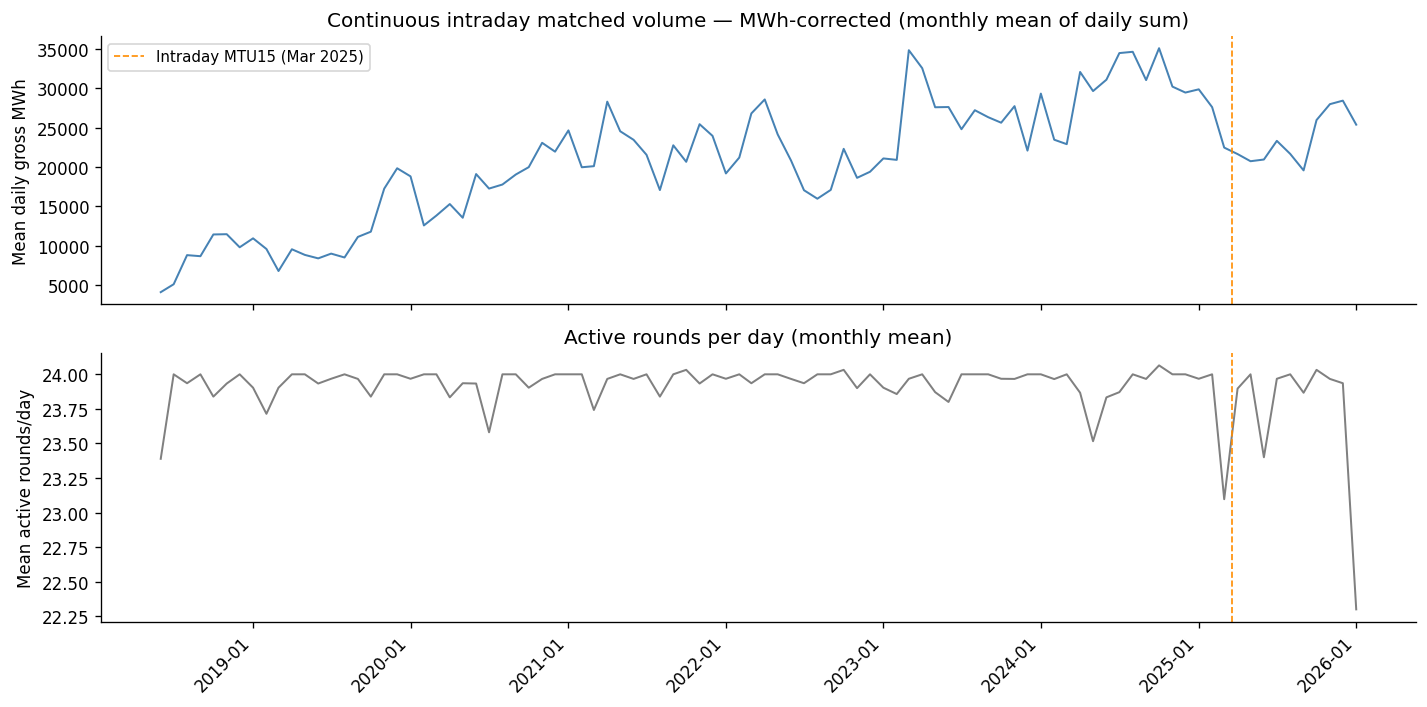

Mean daily gross MWh and active rounds by regime:
  Pre-MTU15  (< 2025-03-19): gross_mwh=20,708  active_rounds=23.9  (n=2471 days)
  Post-MTU15 (≥ 2025-03-19): gross_mwh=23,134  active_rounds=23.8  (n=297 days)


In [16]:
# MWh-corrected volume: |MW| × (mtu_minutes/60) removes the mechanical 4× inflation
# from having 96 periods/day post-reform instead of 24 pre-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily = df_pibcic.groupby("date").agg(
    gross_mwh=("gross_mwh", "sum"),
    active_rounds=("round_number", "nunique"),
).reset_index()

monthly_pibcic = daily.groupby(daily["date"].dt.to_period("M")).agg(
    gross_mwh=("gross_mwh", "mean"),
    active_rounds=("active_rounds", "mean"),
).reset_index()
monthly_pibcic["date"] = monthly_pibcic["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_pibcic["date"], monthly_pibcic["gross_mwh"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="Intraday MTU15 (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MWh")
axes[0].set_title("Continuous intraday matched volume — MWh-corrected (monthly mean of daily sum)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_pibcic["date"], monthly_pibcic["active_rounds"], linewidth=1.2, color="gray")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean active rounds/day")
axes[1].set_title("Active rounds per day (monthly mean)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mean daily gross MWh and active rounds by regime:")
for label, mask in [
    ("Pre-MTU15  (< 2025-03-19)", daily["date"] < INTRADAY_REFORM),
    ("Post-MTU15 (≥ 2025-03-19)", daily["date"] >= INTRADAY_REFORM),
]:
    sub = daily[mask]
    print(f"  {label}: gross_mwh={sub['gross_mwh'].mean():,.0f}  active_rounds={sub['active_rounds'].mean():.1f}  (n={len(sub)} days)")


### 5a-bis. Raw MW-sum vs MWh — the mechanical MTU15 artefact

The raw MW-sum $\sum_\pi |m_{d,r,\pi,i}|$ doubles at the reform because there are $4\times$ more period rows per day under MTU15. The MWh-corrected series $E_d$ (shown in 5a) divides each term by $\delta_\pi/60$, removing this inflation:

$$\underbrace{\sum_\pi |m_{d,\pi}|}_{\text{inflated MW-sum}} \;\approx\; 4 \times \underbrace{\sum_\pi |m_{d,\pi}| \cdot \tfrac{\delta_\pi}{60}}_{\text{corrected MWh}} \quad \text{(post-reform)}$$

This cell shows both side by side to make the mechanical artefact explicit.


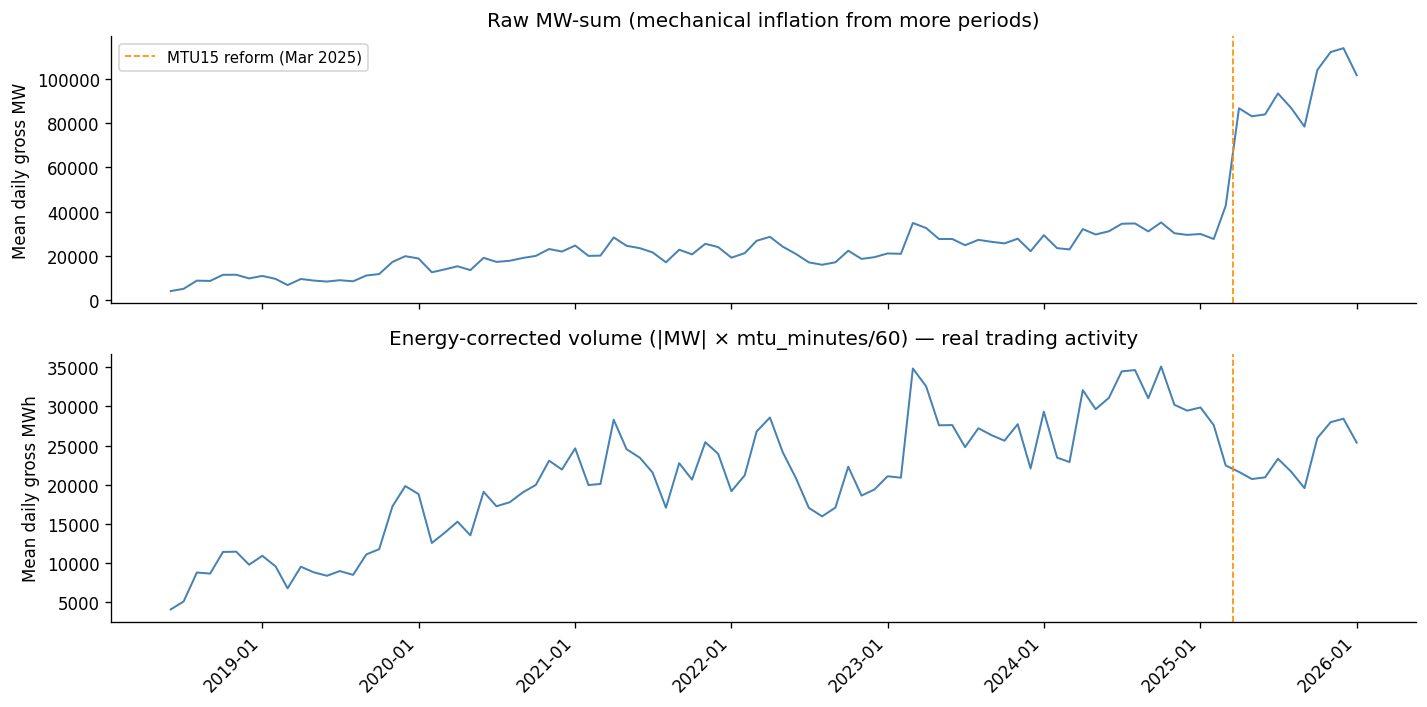

Regime                             Gross MW    Gross MWh   Days
----------------------------------------------------------------
Pre-MTU15  (< 2025-03-19)            20,708       20,708   2471
Post-MTU15 (≥ 2025-03-19)            92,534       23,134    297

Post/pre ratio — MW-sum: 4.47x   MWh: 1.12x
(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)


In [17]:
# Energy-equivalent: MWh = |MW| × (mtu_minutes / 60)
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

daily_energy = df_pibcic.groupby("date").agg(
    gross_mw=("assigned_power_mw", lambda x: x.abs().sum()),
    gross_mwh=("gross_mwh", "sum"),
).reset_index()

monthly_energy = daily_energy.groupby(daily_energy["date"].dt.to_period("M")).agg(
    gross_mw=("gross_mw", "mean"),
    gross_mwh=("gross_mwh", "mean"),
).reset_index()
monthly_energy["date"] = monthly_energy["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(monthly_energy["date"], monthly_energy["gross_mw"], linewidth=1.2, color="steelblue")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1, label="MTU15 reform (Mar 2025)")
axes[0].set_ylabel("Mean daily gross MW")
axes[0].set_title("Raw MW-sum (mechanical inflation from more periods)")
axes[0].legend(fontsize=9)

axes[1].plot(monthly_energy["date"], monthly_energy["gross_mwh"], linewidth=1.2, color="steelblue")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean daily gross MWh")
axes[1].set_title("Energy-corrected volume (|MW| × mtu_minutes/60) — real trading activity")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Regime means
print(f"{'Regime':<30} {'Gross MW':>12} {'Gross MWh':>12} {'Days':>6}")
print("-" * 64)
for label, mask in [
    ("Pre-MTU15  (< 2025-03-19)", daily_energy["date"] < INTRADAY_REFORM),
    ("Post-MTU15 (≥ 2025-03-19)", daily_energy["date"] >= INTRADAY_REFORM),
]:
    sub = daily_energy[mask]
    print(f"{label:<30} {sub['gross_mw'].mean():>12,.0f} {sub['gross_mwh'].mean():>12,.0f} {len(sub):>6}")

ratio_mw  = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mw"].mean()  / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mw"].mean()
ratio_mwh = daily_energy[daily_energy["date"] >= INTRADAY_REFORM]["gross_mwh"].mean() / daily_energy[daily_energy["date"] < INTRADAY_REFORM]["gross_mwh"].mean()
print(f"\nPost/pre ratio — MW-sum: {ratio_mw:.2f}x   MWh: {ratio_mwh:.2f}x")
print(f"(If MWh ratio ≈ MW ratio: break is real. If MWh ratio ≈ 1: purely mechanical.)")

### 5b. Matched volume profile by period — pre vs post MTU15

**Net position per hour.** To compare across MTU regimes, map each delivery period $\pi$ to an hour $h(\pi)$:

$$h(\pi) = \begin{cases} \pi & \text{if MTU60} \\ \lceil \pi / 4 \rceil & \text{if MTU15} \end{cases}$$

Then sum signed matched power within each $(d, h)$ and take the absolute value before averaging across days:

$$\bar{A}_h = \frac{1}{|T_r|} \sum_{t \in T_r} \left| \sum_{\pi : h(\pi)=h} \sum_{r,i} m_{t,r,\pi,i} \right|$$

This collapses the four quarter-hour positions into a single hourly net position, enabling a direct shape comparison between regimes.


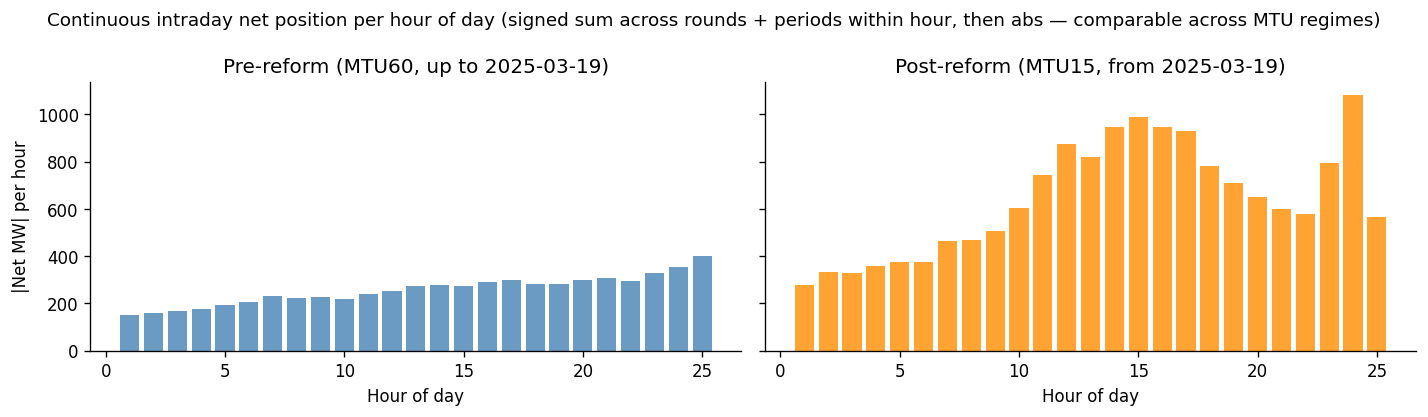

In [18]:
# Aggregate net position to hour-of-day for a fair pre/post comparison.
# Pre-reform: period == hour (1-24). Post-reform: hour = (period-1)//4 + 1.
# Within each (date, hour) sum signed MW across periods, then abs — avoids
# artificially inflating the post-reform profile by counting 4 periods vs 1.
net_period = df_pibcic.groupby(["date", "period"])["assigned_power_mw"].sum().reset_index(name="net_mw")

pre_df  = net_period[net_period["date"] < INTRADAY_REFORM].copy()
post_df = net_period[net_period["date"] >= INTRADAY_REFORM].copy()

pre_df["hour"]  = pre_df["period"]               # MTU60: period == hour
post_df["hour"] = (post_df["period"] - 1) // 4 + 1  # MTU15: 4 periods per hour

# Sum signed MW within each (date, hour), then abs
pre_hourly  = pre_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()
post_hourly = post_df.groupby(["date", "hour"])["net_mw"].sum().abs().groupby("hour").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].bar(pre_hourly.index,  pre_hourly.values,  color="steelblue",  alpha=0.8)
axes[0].set_title(f"Pre-reform (MTU60, up to {INTRADAY_REFORM.date()})")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("|Net MW| per hour")

axes[1].bar(post_hourly.index, post_hourly.values, color="darkorange", alpha=0.8)
axes[1].set_title(f"Post-reform (MTU15, from {INTRADAY_REFORM.date()})")
axes[1].set_xlabel("Hour of day")

plt.suptitle("Continuous intraday net position per hour of day (signed sum across rounds + periods within hour, then abs — comparable across MTU regimes)", fontsize=11)
plt.tight_layout()
plt.show()


### 5c. Intra-hour volume dispersion — post MTU15

Post-reform, each hour $h$ maps to four delivery periods $Q_h = \{4(h-1)+1,\ldots,4h\}$. The intra-hour dispersion in absolute net position is:

$$\bar{\sigma}^{\text{vol}}_h = \frac{1}{|T_{\text{post}}|} \sum_{t \in T_{\text{post}}} \operatorname{std}_{\pi \in Q_h}\!\bigl(\bigl|\textstyle\sum_{r,i} m_{t,r,\pi,i}\bigr|\bigr)$$

A large $\bar{\sigma}^{\text{vol}}_h$ means matched volumes differ substantially across quarter-hours within hour $h$ — a pattern invisible under MTU60.


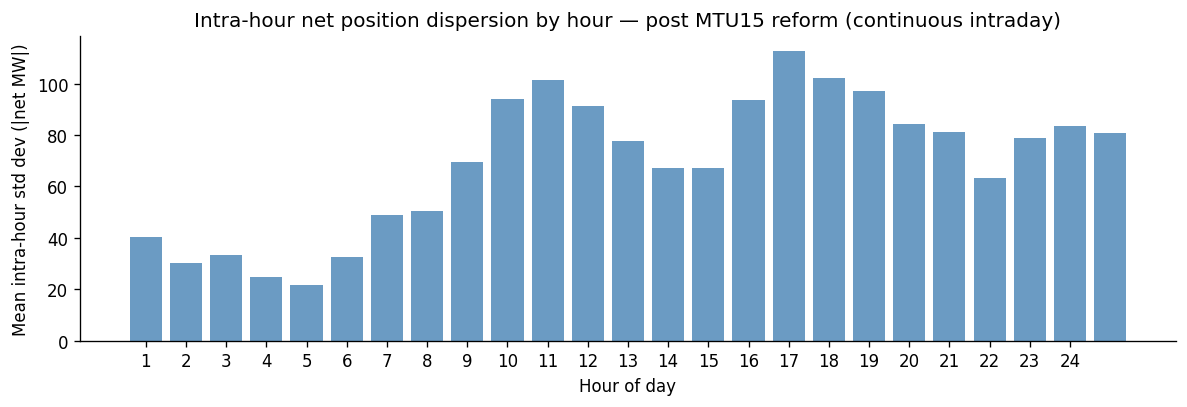

Overall mean intra-hour std dev: 69.1 MW
Max (hour 17): 112.9 MW


In [19]:
post_mtu15_net = net_period[
    (net_period["date"] >= INTRADAY_REFORM) &
    (net_period["date"].isin(df_pibcic[df_pibcic["mtu_minutes"] == 15]["date"].unique()))
].copy()
post_mtu15_net["abs_net_mw"] = post_mtu15_net["net_mw"].abs()
post_mtu15_net["hour"] = ((post_mtu15_net["period"] - 1) // 4) + 1

intra_hour_std_net = (
    post_mtu15_net.groupby(["date", "hour"])["abs_net_mw"]
    .std()
    .reset_index()
    .groupby("hour")["abs_net_mw"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(intra_hour_std_net.index, intra_hour_std_net.values, color="steelblue", alpha=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean intra-hour std dev (|net MW|)")
ax.set_title("Intra-hour net position dispersion by hour — post MTU15 reform (continuous intraday)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

print(f"Overall mean intra-hour std dev: {intra_hour_std_net.mean():.1f} MW")
print(f"Max (hour {intra_hour_std_net.idxmax()}): {intra_hour_std_net.max():.1f} MW")


### 5d. Round-level activity — matched volume per round, pre vs post MTU15

**Round-level energy.** For each day $d$ and round $r$, the gross energy matched in that round is:

$$E_{d,r} = \sum_{\pi, i} |m_{d,r,\pi,i}| \cdot \frac{\delta_\pi}{60}$$

The mean across days, $\bar{E}_r = \frac{1}{|T|}\sum_d E_{d,r}$, shows which rounds carry the most trading activity. Early rounds capture the bulk of pre-positioning; late rounds reflect last-minute rebalancing as the delivery window approaches.


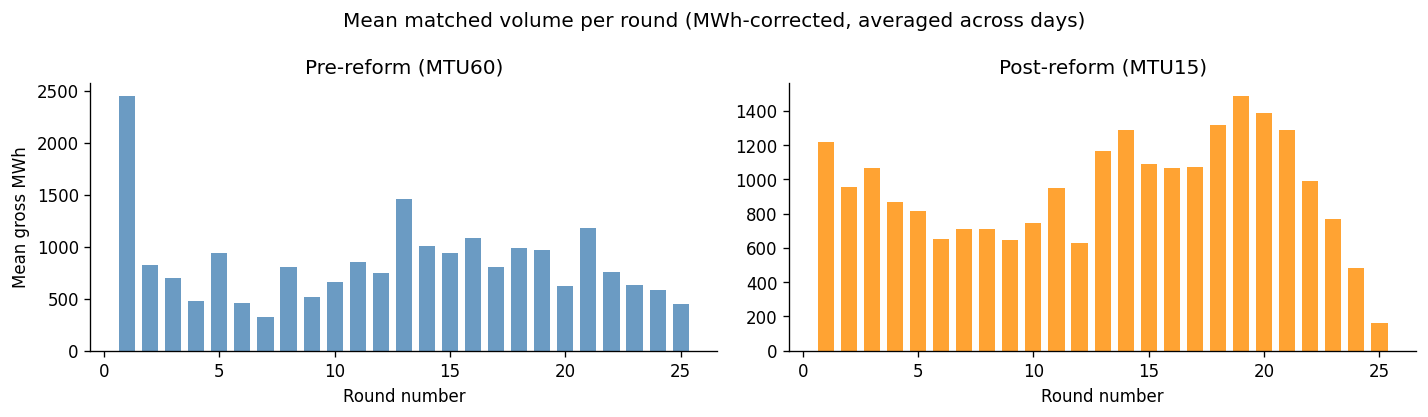

Top 5 rounds by mean matched MWh (pre-reform):
round_number
1     2450.406458
13    1457.179029
21    1176.774818
16    1085.783043
14    1006.489273

Top 5 rounds by mean matched MWh (post-reform):
round_number
19    1486.852778
20    1383.965741
18    1318.170118
14    1289.801627
21    1286.801431


In [20]:
# Round-level matched volume in MWh (|MW| × mtu_minutes/60).
# Using MWh corrects for the 4× more periods per round post-reform.
df_pibcic["gross_mwh"] = df_pibcic["assigned_power_mw"].abs() * df_pibcic["mtu_minutes"] / 60

round_vol = df_pibcic.groupby(["date", "round_number"])["gross_mwh"].sum().reset_index(name="gross_mwh")

pre_round  = round_vol[round_vol["date"] < INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()
post_round = round_vol[round_vol["date"] >= INTRADAY_REFORM].groupby("round_number")["gross_mwh"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].bar(pre_round.index,  pre_round.values,  color="steelblue",  alpha=0.8, width=0.7)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Round number")
axes[0].set_ylabel("Mean gross MWh")

axes[1].bar(post_round.index, post_round.values, color="darkorange", alpha=0.8, width=0.7)
axes[1].set_title("Post-reform (MTU15)")
axes[1].set_xlabel("Round number")

plt.suptitle("Mean matched volume per round (MWh-corrected, averaged across days)", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 rounds by mean matched MWh (pre-reform):")
print(pre_round.nlargest(5).to_string())
print()
print("Top 5 rounds by mean matched MWh (post-reform):")
print(post_round.nlargest(5).to_string())


---
## Section 6 — Continuous intraday accumulated programs (`pibcac`)

Data: `pibcac_all.parquet` — cumulative scheduled MW per unit after each round. Unlike PIBCIC (incremental change per round), each PIBCAC snapshot contains the **full accumulated position** for every unit × period at the end of round $r$:

$$A_{d,r,\pi,i} = \sum_{r' \leq r} m_{d,r',\pi,i}$$

**2.7 billion rows** — 59,299 files, 2018-06-13 → 2026-01-10.

> **Data availability gap**: OMIE ZIP archives for 2025-04 through 2025-12 return HTTP 500 — those months are not publicly available. Post-reform coverage is limited to 2025-03-19 → 2025-03-31 (13 days) and 2026-01-01 → 2026-01-10 (10 days). Cross-regime comparisons should be interpreted with caution.

> **Interpretive caveat**: PIBCAC records only *matched* power. Rejected offers are not observed. Total matched volume is bounded by system demand.


In [21]:
PIBCAC = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/programas/pibcac_all.parquet"

# Load via DuckDB — too large for full in-memory pandas
con_ac = duckdb.connect()

# Sample check
info = con_ac.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT date) AS n_days,
        MIN(date) AS date_min,
        MAX(date) AS date_max,
        COUNT(DISTINCT unit_code) AS n_units
    FROM read_parquet('{PIBCAC}')
""").fetchone()
print(f"Rows: {info[0]:,}  Days: {info[1]}  Range: {info[2]} -> {info[3]}  Units: {info[4]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 2,691,641,468  Days: 2480  Range: 2018-06-13 -> 2026-01-10  Units: 5567


### 6a. Daily last-round accumulated volume over time

The final settled state on day $d$ is the position at the last round $R_d = \max_r$. Total accumulated volume (MWh-corrected):

$$V_d = \sum_{\pi, i} \bigl|A_{d,R_d,\pi,i}\bigr| \cdot \frac{\delta_\pi}{60}$$

This is the total energy scheduled through the continuous intraday market as of market close.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

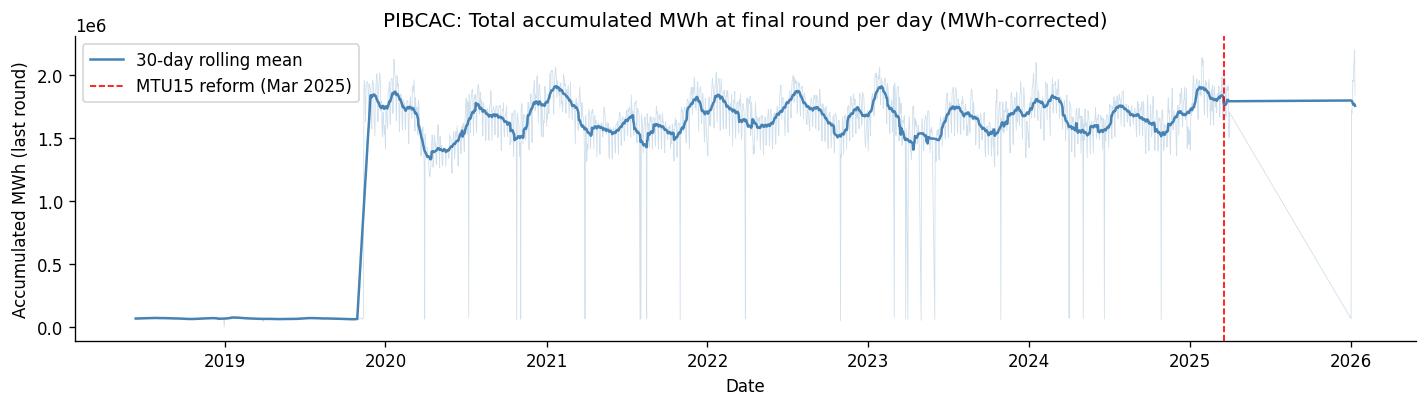

Pre-reform mean:  1,327,853 MWh
Post-reform mean: 1,795,048 MWh
Ratio (post/pre): 1.35x
(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)


In [22]:
# MWh-corrected: multiply |MW| by mtu_minutes/60 to remove the mechanical 4× inflation
# from 96 periods/day (MTU15) vs 24 (MTU60).
daily_last = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date,
           SUM(ABS(p.assigned_power_mw) * p.mtu_minutes / 60.0) AS total_mwh
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date
    ORDER BY p.date
""").df()

daily_last["date"] = pd.to_datetime(daily_last["date"])
daily_last["smoothed"] = daily_last["total_mwh"].rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily_last["date"], daily_last["total_mwh"], alpha=0.25, color="steelblue", linewidth=0.5)
ax.plot(daily_last["date"], daily_last["smoothed"], color="steelblue", linewidth=1.5, label="30-day rolling mean")
ax.axvline(INTRADAY_REFORM, color="red", linestyle="--", linewidth=1, label="MTU15 reform (Mar 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Accumulated MWh (last round)")
ax.set_title("PIBCAC: Total accumulated MWh at final round per day (MWh-corrected)")
ax.legend()
plt.tight_layout()
plt.show()

pre_mean  = daily_last.loc[daily_last["date"] < INTRADAY_REFORM, "total_mwh"].mean()
post_mean = daily_last.loc[daily_last["date"] >= INTRADAY_REFORM, "total_mwh"].mean()
print(f"Pre-reform mean:  {pre_mean:,.0f} MWh")
print(f"Post-reform mean: {post_mean:,.0f} MWh")
print(f"Ratio (post/pre): {post_mean/pre_mean:.2f}x")
print("(Ratio ~1 = no change in matched energy; MWh corrects for extra periods post-reform)")


### 6b. Accumulated position profile by hour of day — pre vs post MTU15

Mean accumulated MW per hour of day at the final round, averaged across days. Both regimes mapped to hours 1–24 via $h(\pi)$ (see §5b). The buy/sell asymmetry by hour reveals which delivery windows attract the most net trading activity.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

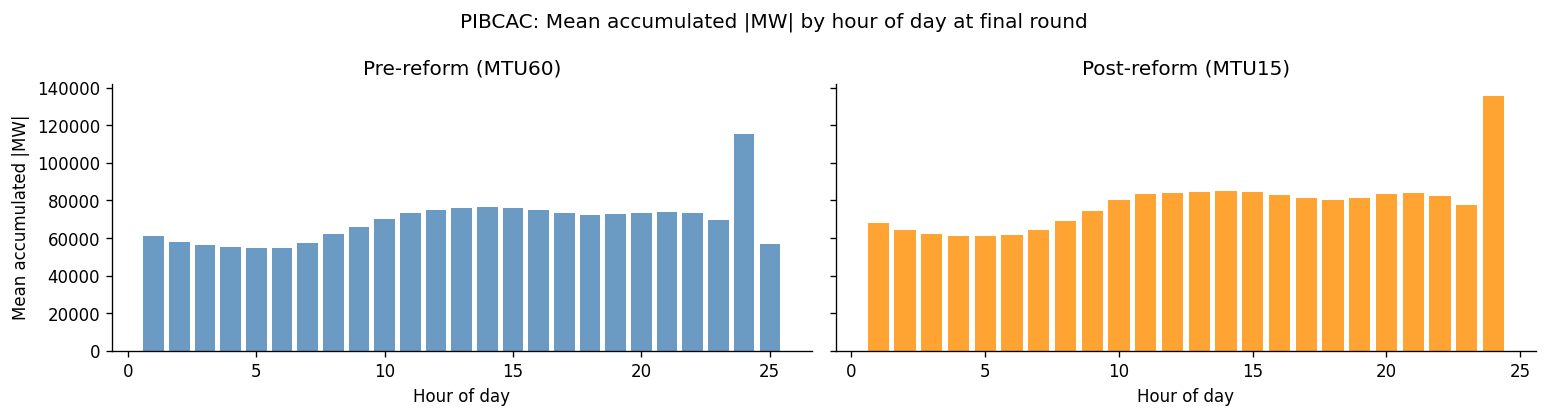

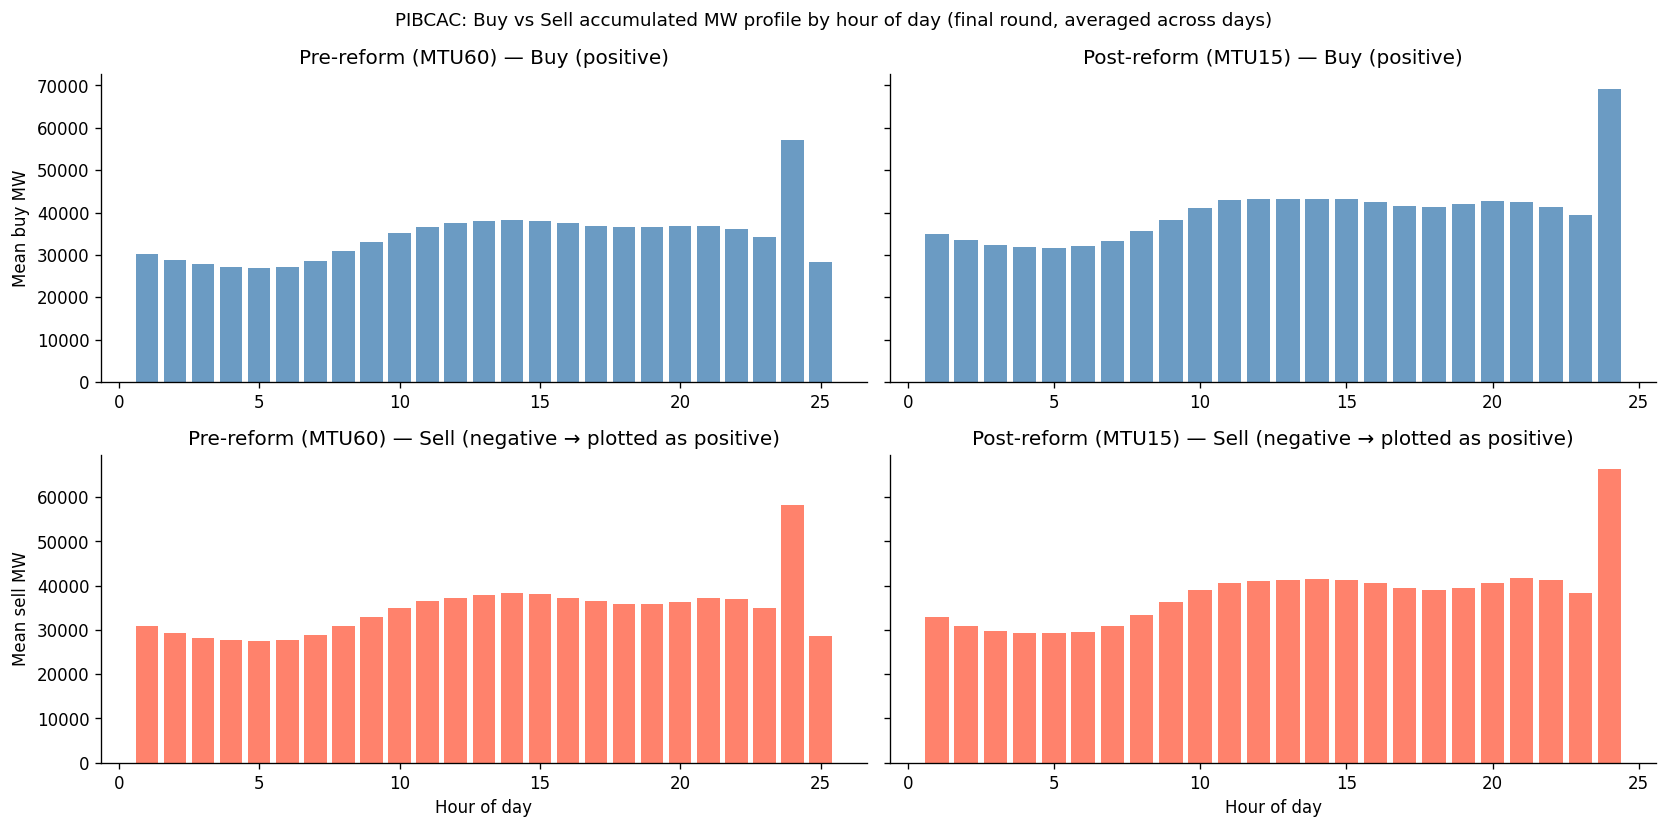

In [23]:
period_profile = con_ac.execute(f"""
    WITH last_round AS (
        SELECT date, MAX(round_number) AS last_round
        FROM read_parquet('{PIBCAC}')
        GROUP BY date
    )
    SELECT p.date, p.period, p.mtu_minutes,
           SUM(CASE WHEN p.assigned_power_mw > 0 THEN  p.assigned_power_mw ELSE 0 END) AS buy_mw,
           SUM(CASE WHEN p.assigned_power_mw < 0 THEN -p.assigned_power_mw ELSE 0 END) AS sell_mw,
           SUM(ABS(p.assigned_power_mw)) AS abs_mw
    FROM read_parquet('{PIBCAC}') p
    JOIN last_round l ON p.date = l.date AND p.round_number = l.last_round
    GROUP BY p.date, p.period, p.mtu_minutes
    ORDER BY p.date, p.period
""").df()

period_profile["date"] = pd.to_datetime(period_profile["date"])

# Map period → hour: MTU60 period==hour; MTU15 hour = (period-1)//4 + 1
period_profile["hour"] = period_profile.apply(
    lambda r: int(r["period"]) if r["mtu_minutes"] == 60 else (int(r["period"]) - 1) // 4 + 1,
    axis=1
)

pre_df  = period_profile[period_profile["date"] < INTRADAY_REFORM]
post_df = period_profile[period_profile["date"] >= INTRADAY_REFORM]

def hourly_mean(df, col):
    return df.groupby(["date", "hour"])[col].mean().groupby("hour").mean()

pre_buy   = hourly_mean(pre_df,  "buy_mw")
pre_sell  = hourly_mean(pre_df,  "sell_mw")
post_buy  = hourly_mean(post_df, "buy_mw")
post_sell = hourly_mean(post_df, "sell_mw")
pre_abs   = hourly_mean(pre_df,  "abs_mw")
post_abs  = hourly_mean(post_df, "abs_mw")

# ── Plot: |MW| profile pre/post (original) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
axes[0].bar(pre_abs.index,  pre_abs.values,  color="steelblue",  alpha=0.8)
axes[0].set_title("Pre-reform (MTU60)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Mean accumulated |MW|")
axes[1].bar(post_abs.index, post_abs.values, color="darkorange", alpha=0.8)
axes[1].set_title("Post-reform (MTU15)")
axes[1].set_xlabel("Hour of day")
plt.suptitle("PIBCAC: Mean accumulated |MW| by hour of day at final round", fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot: buy vs sell profile pre/post ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey="row")
width = 0.4

for col_idx, (regime, buy, sell, label) in enumerate([
    ("Pre-reform (MTU60)",  pre_buy,  pre_sell,  f"up to {INTRADAY_REFORM.date()}"),
    ("Post-reform (MTU15)", post_buy, post_sell, f"from {INTRADAY_REFORM.date()}"),
]):
    ax_buy  = axes[0][col_idx]
    ax_sell = axes[1][col_idx]
    ax_buy.bar(buy.index,  buy.values,  color="steelblue", alpha=0.8, width=0.8)
    ax_sell.bar(sell.index, sell.values, color="tomato",    alpha=0.8, width=0.8)
    ax_buy.set_title(f"{regime} — Buy (positive)")
    ax_sell.set_title(f"{regime} — Sell (negative → plotted as positive)")
    ax_sell.set_xlabel("Hour of day")
    if col_idx == 0:
        axes[0][0].set_ylabel("Mean buy MW")
        axes[1][0].set_ylabel("Mean sell MW")

plt.suptitle("PIBCAC: Buy vs Sell accumulated MW profile by hour of day (final round, averaged across days)", fontsize=11)
plt.tight_layout()
plt.show()


### 6c. Round-by-round accumulation — how does the schedule build up?

For a representative pre-reform day, plot total accumulated $\sum_{\pi,i} |A_{d,r,\pi,i}|$ after each round $r$.

**Non-monotonicity.** The accumulated $|MW|$ is not necessarily monotone because participants can reduce or cancel their continuous-market positions between rounds:

$$A_{d,r,\pi,i} = A_{d,r-1,\pi,i} + m_{d,r,\pi,i}, \quad m_{d,r,\pi,i} \in \mathbb{R}$$

The common pattern is a gradual reduction in early rounds (net cancellations) followed by a sharp spike in final rounds as end-of-day rebalancing concentrates just before delivery.

**Note:** The x-axis is the sequential round index (1 to ~21), not the delivery period.


Sample day: 2025-03-18 (24 rounds)


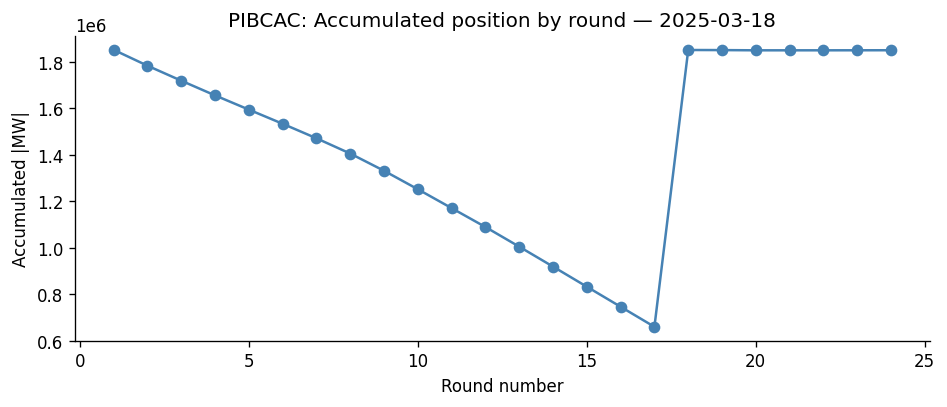

In [24]:
# Pick the most recent day with the most rounds
sample_day_row = con_ac.execute(f"""
    SELECT date, MAX(round_number) AS n_rounds
    FROM read_parquet('{PIBCAC}')
    WHERE date >= '{(INTRADAY_REFORM - pd.Timedelta(days=90)).date()}'
      AND date < '{INTRADAY_REFORM.date()}'
    GROUP BY date
    ORDER BY n_rounds DESC, date DESC
    LIMIT 1
""").fetchone()
sample_day = sample_day_row[0]
print(f"Sample day: {sample_day} ({sample_day_row[1]} rounds)")

round_accum = con_ac.execute(f"""
    SELECT round_number, SUM(ABS(assigned_power_mw)) AS total_abs_mw
    FROM read_parquet('{PIBCAC}')
    WHERE date = '{sample_day}'
    GROUP BY round_number
    ORDER BY round_number
""").df()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(round_accum["round_number"], round_accum["total_abs_mw"], marker="o", color="steelblue")
ax.set_xlabel("Round number")
ax.set_ylabel("Accumulated |MW|")
ax.set_title(f"PIBCAC: Accumulated position by round — {sample_day}")
plt.tight_layout()
plt.show()

---
## Section 7 — Day-ahead offers by technology (`cab` + `det` + `lista_unidades`)

Data: `det_all` (price/quantity per offer × period) joined to `cab_all` (offer headers with `unit_code`), then mapped to technology via `lista_unidades.csv`.

**Technology-level supply curve.** The aggregate offer curve for technology group $g$ in period $\pi$ is:

$$Q^{S,g}_\pi(p) = \sum_{i \in g} q_{i,\pi} \cdot \mathbf{1}[c_{i,\pi} \leq p]$$

Stacking across groups gives the full merit order. The reform moves from $|\Pi| = 24$ to $|\Pi| = 96$, enabling finer intraday price differentiation by technology.

**Coverage:** 2018-01-01 → 2026-01-09. ~25% of historical unit codes are not in the current `lista_unidades` (deactivated units) and appear as **Other/Unknown**. All volume figures use MWh-correction ($\text{MW} \times \delta_\pi / 60$) for pre/post comparability.


In [25]:
CAB   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/cab_all.parquet"
DET   = PROJECT_ROOT / "data/processed/omie/mercado_diario/ofertas/det_all.parquet"
UNITS = PROJECT_ROOT / "data/external/omie_reference/lista_unidades.csv"

con_det = duckdb.connect()

TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

TECH_COLORS = {
    'Solar':             '#f4a41b',
    'Wind':              '#4a90d9',
    'Hydro':             '#1565c0',
    'CCGT':              '#e53935',
    'Nuclear':           '#8e24aa',
    'Thermal (non-RES)': '#795548',
    'Thermal (RES)':     '#43a047',
    'Other/Unknown':     '#bdbdbd',
}
TECH_ORDER = ['Nuclear', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Thermal (RES)', 'Wind', 'Solar', 'Other/Unknown']

# Quick coverage check (sell-side only)
cov = con_det.execute(f"""
    SELECT {TECH_SQL} AS tech_group,
           COUNT(DISTINCT c.unit_code) AS n_units,
           COUNT(DISTINCT c.date)      AS n_days,
           ROUND(SUM(1) / 1e3, 0)     AS n_offers_k
    FROM read_parquet('{CAB}') c
    LEFT JOIN read_csv('{UNITS}') u ON c.unit_code = u.unit_code
    WHERE c.buy_sell = 'V'
    GROUP BY 1 ORDER BY n_offers_k DESC
""").df()
print("Sell-side offer headers by technology:")
print(cov.to_string(index=False))


Sell-side offer headers by technology:
       tech_group  n_units  n_days  n_offers_k
    Other/Unknown     1389    3296      1168.0
            Solar     1214    3296       993.0
Thermal (non-RES)      365    3296       559.0
             Wind      392    3296       558.0
            Hydro      272    3296       461.0
    Thermal (RES)       95    3296       156.0
             CCGT       57    3296       154.0
          Nuclear        7    3296        48.0


### 7a. Sell-side offer volume by technology over time

Daily MWh offered per technology (sell side, MWh-corrected): $V^g_d = \sum_{i \in g, \pi} q_{i,\pi,d} \cdot \delta_\pi / 60$.

The stacked area shows the evolving technology mix over 2018–2026. The vertical dashed line marks the day-ahead MTU15 reform (2025-10-01).

> **Runtime note:** full scan of ~172 M det rows — expect ~2–3 min.


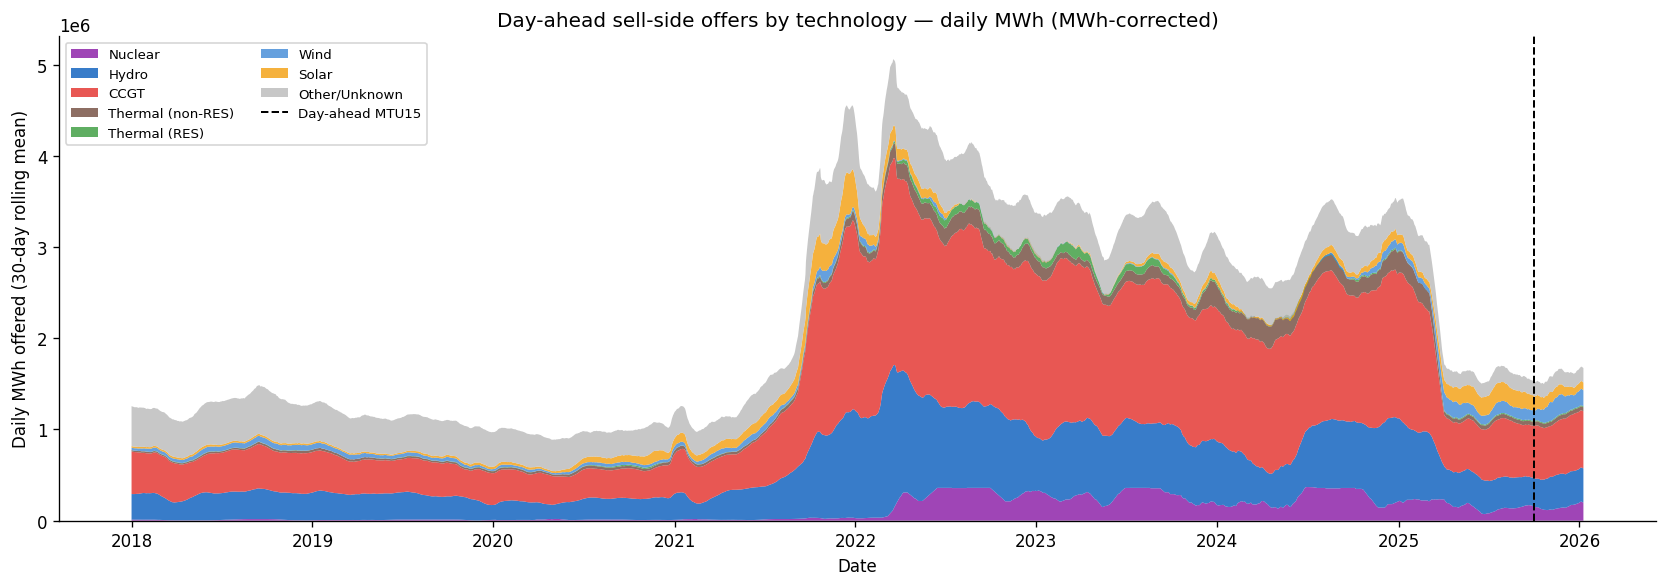

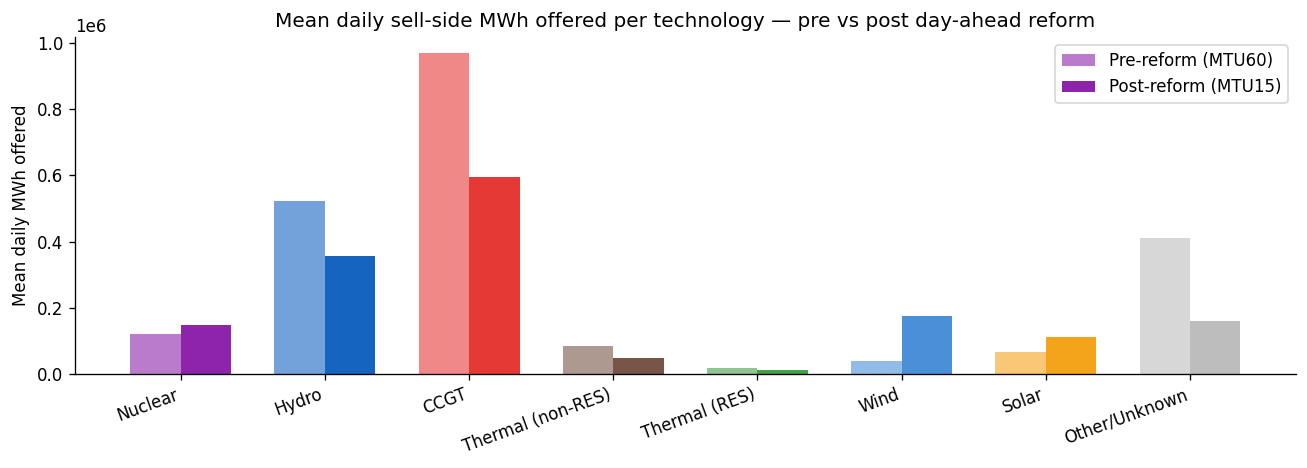

In [26]:
daily_tech = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT b.date,
           CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END AS tech_group,
           SUM(b.quantity_mw * b.mtu_minutes / 60.0) AS mwh
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY b.date, tech_group
    ORDER BY b.date, tech_group
""").df()

daily_tech["date"] = pd.to_datetime(daily_tech["date"])

# Pivot and smooth for stacked area chart
pivot = daily_tech.pivot_table(index="date", columns="tech_group", values="mwh", aggfunc="sum").fillna(0)
pivot = pivot[[c for c in TECH_ORDER if c in pivot.columns]]
pivot_smooth = pivot.rolling(30, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    pivot_smooth.index,
    [pivot_smooth[c] for c in pivot_smooth.columns],
    labels=pivot_smooth.columns,
    colors=[TECH_COLORS[c] for c in pivot_smooth.columns],
    alpha=0.85,
)
ax.axvline(DAY_AHEAD_REFORM, color="black", linestyle="--", linewidth=1.2, label="Day-ahead MTU15")
ax.set_xlabel("Date")
ax.set_ylabel("Daily MWh offered (30-day rolling mean)")
ax.set_title("Day-ahead sell-side offers by technology — daily MWh (MWh-corrected)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Pre / post bar comparison (mean daily MWh per technology)
pre  = daily_tech[daily_tech["date"] <  DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
post = daily_tech[daily_tech["date"] >= DAY_AHEAD_REFORM].groupby("tech_group")["mwh"].mean()
comp = pd.DataFrame({"Pre-reform (MTU60)": pre, "Post-reform (MTU15)": post}).reindex(TECH_ORDER).dropna(how="all")

fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(comp))
w = 0.35
ax.bar([i - w/2 for i in x], comp["Pre-reform (MTU60)"], width=w, label="Pre-reform (MTU60)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=0.6)
ax.bar([i + w/2 for i in x], comp["Post-reform (MTU15)"], width=w, label="Post-reform (MTU15)",
       color=[TECH_COLORS[t] for t in comp.index], alpha=1.0)
ax.set_xticks(list(x))
ax.set_xticklabels(comp.index, rotation=20, ha="right")
ax.set_ylabel("Mean daily MWh offered")
ax.set_title("Mean daily sell-side MWh offered per technology — pre vs post day-ahead reform")
ax.legend()
plt.tight_layout()
plt.show()


### 7b. Merit order: bid price distribution by technology

**Merit order.** Units are dispatched in increasing order of bid price $c_{i,\pi}$. The P10/P50/P90 of the submitted bid-price distribution for technology group $g$ characterises where each technology sits in the merit order:

$$\tilde{c}^g_\alpha = \hat{F}_g^{-1}(\alpha), \quad \hat{F}_g(p) = \frac{\sum_{i \in g, \pi} q_{i,\pi}\,\mathbf{1}[c_{i,\pi} \leq p]}{\sum_{i \in g, \pi} q_{i,\pi}}$$

**Note on data availability:** The pre-reform DET format (57-char lines, before 2025-03-19) does not contain bid prices — that field is always 0. OMIE started publishing unit-level bid prices with the new 60-char format from **2025-03-19** onward. The analysis covers only 2025-03-19+, split at the day-ahead reform (2025-10-01).


       tech_group                        regime         p10        p50         p90  n_rows
             CCGT Post day-ahead reform (MTU15)   82.760449 116.265757  678.527635 1975480
             CCGT  Pre day-ahead reform (MTU60)   87.399857 125.741390  920.956387  861676
            Hydro Post day-ahead reform (MTU15)  -23.237296   1.410209  371.133748 3214189
            Hydro  Pre day-ahead reform (MTU60)  -22.333038   0.077485  373.880799 1559639
          Nuclear Post day-ahead reform (MTU15) -500.000000 -50.000000 2999.000000  152552
          Nuclear  Pre day-ahead reform (MTU60) -500.000000 -15.000000 2999.000000   80774
    Other/Unknown Post day-ahead reform (MTU15)  -28.429570  -0.000004  178.184159 1735349
    Other/Unknown  Pre day-ahead reform (MTU60)  -31.431064  -0.198944  138.866344 1073877
            Solar Post day-ahead reform (MTU15)  -31.000031 -14.746105    0.766009 4641351
            Solar  Pre day-ahead reform (MTU60)  -44.637805 -10.000031    1.025079 2659503

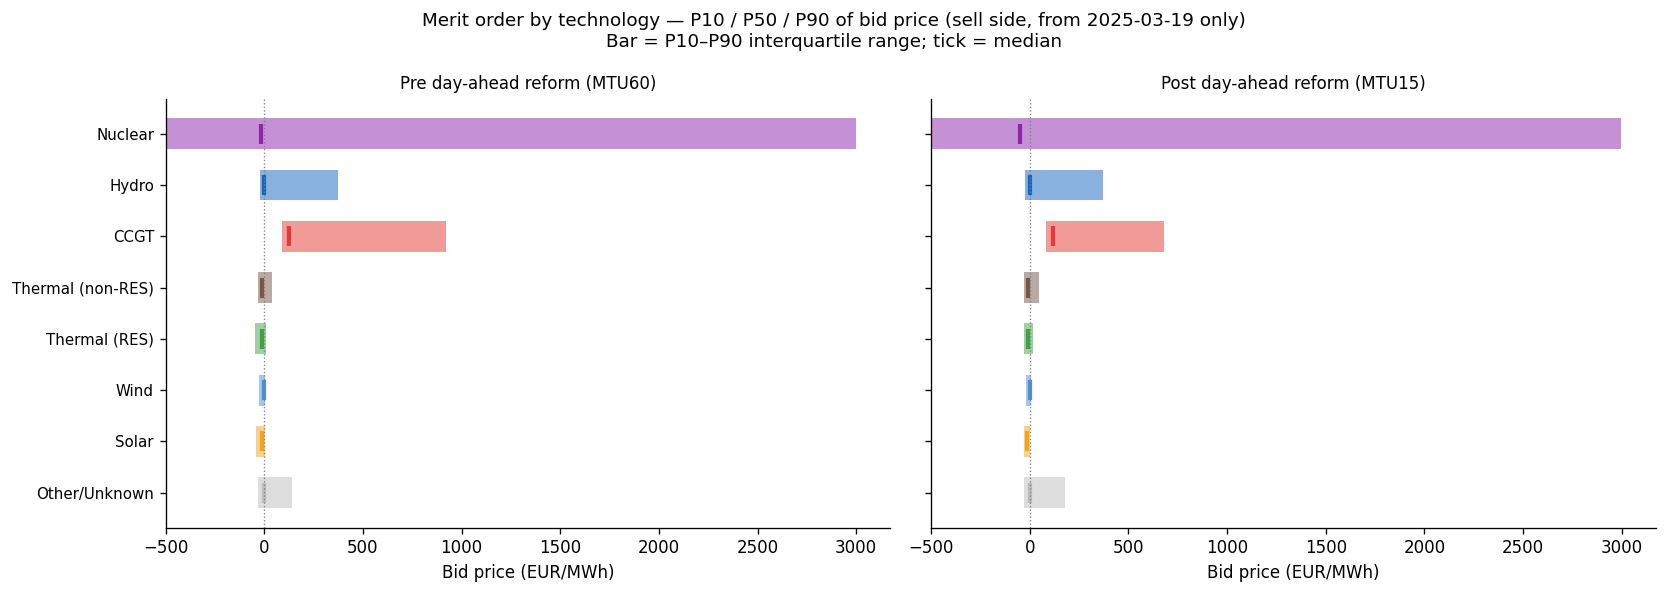

In [27]:
TECH_SQL = """CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END"""

price_dist = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.price_eur_mwh, d.quantity_mw, c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        -- Only use data where OMIE publishes bid prices (new format from 2025-03-19)
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
    )
    SELECT {TECH_SQL}                                              AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}'
                THEN 'Pre day-ahead reform (MTU60)'
                ELSE 'Post day-ahead reform (MTU15)' END          AS regime,
           APPROX_QUANTILE(b.price_eur_mwh, 0.10)                AS p10,
           APPROX_QUANTILE(b.price_eur_mwh, 0.50)                AS p50,
           APPROX_QUANTILE(b.price_eur_mwh, 0.90)                AS p90,
           COUNT(*)                                               AS n_rows
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print(price_dist.to_string(index=False))

regimes  = ["Pre day-ahead reform (MTU60)", "Post day-ahead reform (MTU15)"]
techs    = [t for t in TECH_ORDER if t in price_dist["tech_group"].values]
n_tech   = len(techs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for col_i, regime in enumerate(regimes):
    ax  = axes[col_i]
    sub = price_dist[price_dist["regime"] == regime].set_index("tech_group")
    for i, tech in enumerate(reversed(techs)):
        if tech not in sub.index:
            continue
        row   = sub.loc[tech]
        color = TECH_COLORS[tech]
        ax.barh(i, row["p90"] - row["p10"], left=row["p10"],
                height=0.6, color=color, alpha=0.5)
        ax.plot(row["p50"], i, marker="|", color=color, markersize=12, markeredgewidth=2.5)
    ax.set_yticks(list(range(n_tech)))
    ax.set_yticklabels(list(reversed(techs)), fontsize=9)
    ax.set_xlabel("Bid price (EUR/MWh)")
    ax.set_title(regime, fontsize=10)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

fig.suptitle(
    "Merit order by technology — P10 / P50 / P90 of bid price (sell side, from 2025-03-19 only)\n"
    "Bar = P10–P90 interquartile range; tick = median",
    fontsize=11
)
plt.tight_layout()
plt.show()


### 7c. Within-day bid price variability by technology

**Does the reform enable finer intraday price differentiation?**

For each sell-side offer on a given day, compute the quantity-weighted average bid price per period, then the standard deviation across periods:

$$\sigma^{\text{bid}}_{i,d} = \operatorname{std}_{\pi}\!\left(\frac{\sum_k c_{i,\pi,k}\,q_{i,\pi,k}}{\sum_k q_{i,\pi,k}}\right)$$

A large $\sigma^{\text{bid}}$ indicates the unit prices very differently at different hours (or quarter-hours). Under MTU15, units can express finer intraday price variation — we expect $\sigma^{\text{bid}}$ to rise for flexible technologies (CCGT, Hydro) and remain near zero for must-run generators (Nuclear, Solar when subsidised).

Uses 2025-03-19+ only (when bid prices became available).


Within-day bid price variability by technology and regime:
       tech_group                        regime   mean_std   median_std  n_obs
             CCGT Post day-ahead reform (MTU15) 164.497436 1.080148e+02   4743
             CCGT  Pre day-ahead reform (MTU60) 189.710305 1.508166e+02   8894
            Hydro Post day-ahead reform (MTU15)   2.635822 0.000000e+00  18690
            Hydro  Pre day-ahead reform (MTU60)   3.015693 0.000000e+00  35954
          Nuclear Post day-ahead reform (MTU15)  21.097112 2.837627e-15   1364
          Nuclear  Pre day-ahead reform (MTU60)  38.303596 0.000000e+00   2565
    Other/Unknown Post day-ahead reform (MTU15)   2.617689 0.000000e+00  19699
    Other/Unknown  Pre day-ahead reform (MTU60)   2.666192 1.804095e-20  46498
            Solar Post day-ahead reform (MTU15)   1.208252 0.000000e+00 107558
            Solar  Pre day-ahead reform (MTU60)   1.403616 0.000000e+00 181842
    Thermal (RES) Post day-ahead reform (MTU15)   0.200578 0.000000e+00 

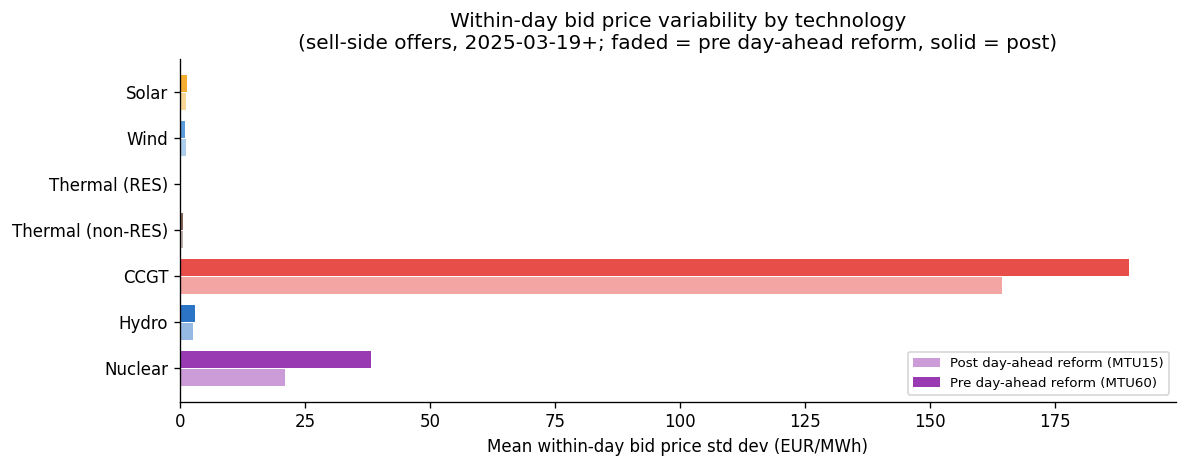

In [28]:
intra_day_std = con_det.execute(f"""
    WITH period_price AS (
        -- Quantity-weighted mean price per (date, offer_code, period)
        SELECT d.date, d.offer_code, d.period, c.unit_code,
               SUM(d.price_eur_mwh * ABS(d.quantity_mw))
                   / NULLIF(SUM(ABS(d.quantity_mw)), 0) AS wavg_price,
               CASE
                   WHEN d.date < '{DAY_AHEAD_REFORM.date()}'
                   THEN 'Pre day-ahead reform (MTU60)'
                   ELSE 'Post day-ahead reform (MTU15)'
               END AS regime
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE d.date >= '2025-03-19'
          AND c.buy_sell = 'V'
        GROUP BY d.date, d.offer_code, d.period, c.unit_code, regime
    ),
    daily_std AS (
        SELECT date, offer_code, unit_code, regime,
               STDDEV(wavg_price) AS price_std
        FROM period_price
        GROUP BY date, offer_code, unit_code, regime
        HAVING COUNT(*) >= 4
    )
    SELECT {TECH_SQL} AS tech_group,
           regime,
           AVG(s.price_std)                   AS mean_std,
           APPROX_QUANTILE(s.price_std, 0.50) AS median_std,
           COUNT(*)                           AS n_obs
    FROM daily_std s
    LEFT JOIN read_csv('{UNITS}') u ON s.unit_code = u.unit_code
    GROUP BY tech_group, regime
    ORDER BY tech_group, regime
""").df()

print('Within-day bid price variability by technology and regime:')
print(intra_day_std.to_string(index=False))
print()

main_techs = [t for t in TECH_ORDER if t != 'Other/Unknown']
regimes_avail = sorted(intra_day_std['regime'].unique())
n_reg = len(regimes_avail)
width = 0.8 / max(n_reg, 1)
alpha_levels = [0.45, 0.9]  # faded=pre, solid=post

fig, ax = plt.subplots(figsize=(10, 4))
for i, regime in enumerate(regimes_avail):
    rdf = (
        intra_day_std[intra_day_std['regime'] == regime]
        .set_index('tech_group')
        .reindex(main_techs)
    )
    offset = (i - (n_reg - 1) / 2) * width
    ax.barh(
        [j + offset for j in range(len(main_techs))],
        rdf['mean_std'].fillna(0),
        height=width * 0.92,
        color=[TECH_COLORS[t] for t in main_techs],
        alpha=alpha_levels[i] if i < len(alpha_levels) else 0.7,
        label=regime,
    )

ax.set_yticks(range(len(main_techs)))
ax.set_yticklabels(main_techs)
ax.set_xlabel('Mean within-day bid price std dev (EUR/MWh)')
ax.set_title(
    'Within-day bid price variability by technology\n'
    '(sell-side offers, 2025-03-19+; faded = pre day-ahead reform, solid = post)'
)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


### 7d. Intraday offer profile by technology and hour of day

**Technology-hour offer profile.** Mean quantity offered (MW) per technology and hour, averaged across days in each regime:

$$\bar{q}^g_h = \frac{1}{|T_r|} \sum_{d \in T_r} \sum_{\pi : h(\pi)=h} \sum_{i \in g} q_{i,\pi,d}$$

Both MTU60 and MTU15 data are mapped to hours 1–24. The stacked view reveals how the technology mix shapes the supply curve at each hour of day, and whether this shape changed after the reform.


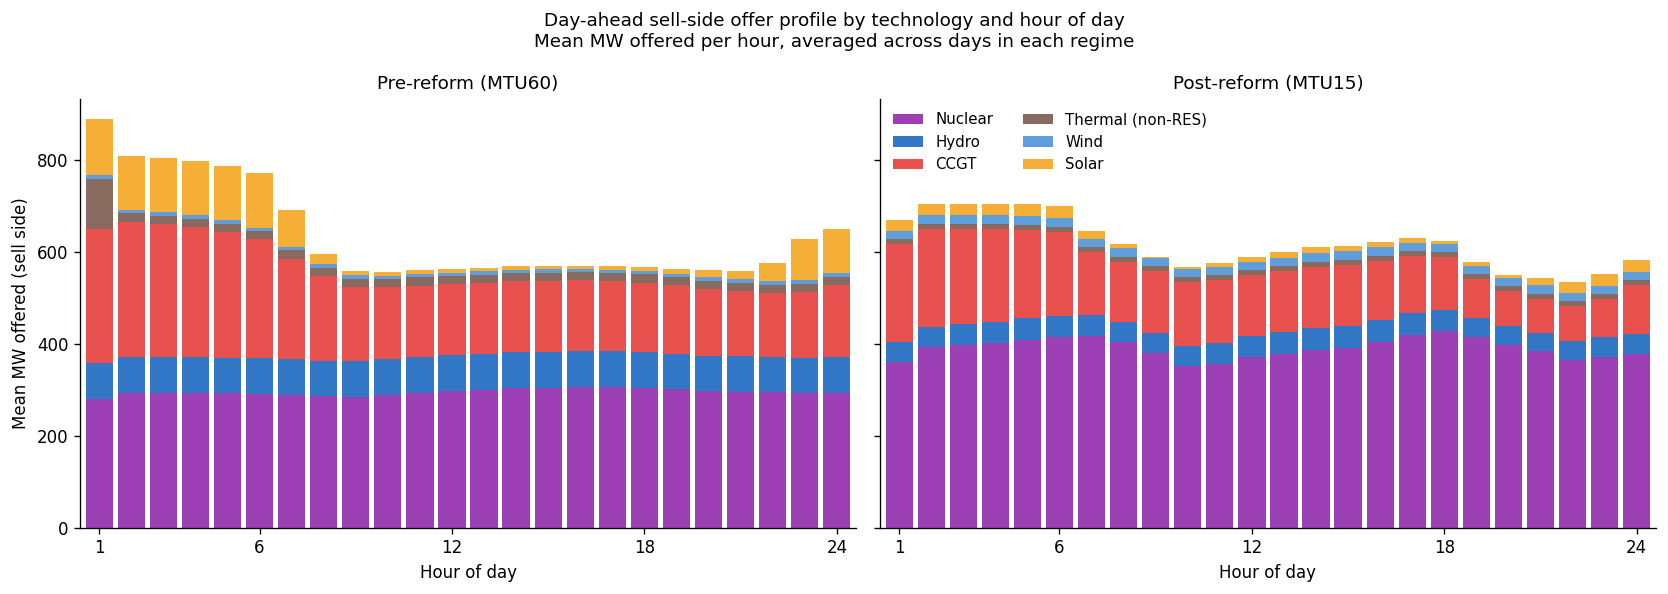

Technology            Pre peak hour  Post peak hour
---------------------------------------------------
Nuclear                          16              18
Hydro                            16              15
CCGT                              2               1
Thermal (non-RES)                 1               4
Wind                              1              15
Solar                             1               6


In [29]:
profile = con_det.execute(f"""
    WITH base AS (
        SELECT d.date, d.quantity_mw, d.mtu_minutes,
               CASE WHEN d.mtu_minutes = 60 THEN CAST(d.period AS INT)
                    ELSE (CAST(d.period AS INT) - 1) / 4 + 1
               END AS hour_of_day,
               c.unit_code
        FROM read_parquet('{DET}') d
        JOIN read_parquet('{CAB}') c
          ON d.date = c.date AND d.offer_code = c.offer_code
        WHERE c.buy_sell = 'V'
    )
    SELECT CASE
        WHEN u.technology IN ('RE Mercado Solar Fotovoltáica', 'RE Mercado Solar Térmica') THEN 'Solar'
        WHEN u.technology = 'RE Mercado Eólica'                                             THEN 'Wind'
        WHEN u.technology IN ('RE Mercado Hidráulica', 'Hidráulica Generación')             THEN 'Hydro'
        WHEN u.technology = 'Ciclo Combinado'                                               THEN 'CCGT'
        WHEN u.technology = 'Nuclear'                                                       THEN 'Nuclear'
        WHEN u.technology = 'RE Mercado Térmica no Renovab.'                               THEN 'Thermal (non-RES)'
        WHEN u.technology = 'RE Mercado Térmica Renovable'                                 THEN 'Thermal (RES)'
        ELSE 'Other/Unknown'
    END                  AS tech_group,
           CASE WHEN b.date < '{DAY_AHEAD_REFORM.date()}' THEN 'Pre-reform (MTU60)'
                ELSE 'Post-reform (MTU15)' END AS regime,
           hour_of_day,
           AVG(b.quantity_mw)          AS mean_mw
    FROM base b
    LEFT JOIN read_csv('{UNITS}') u ON b.unit_code = u.unit_code
    WHERE hour_of_day BETWEEN 1 AND 24
    GROUP BY tech_group, regime, hour_of_day
    ORDER BY tech_group, regime, hour_of_day
""").df()

focus_techs = ['Nuclear', 'Hydro', 'CCGT', 'Thermal (non-RES)', 'Wind', 'Solar']
regimes     = ["Pre-reform (MTU60)", "Post-reform (MTU15)"]

def regime_pivot(df, regime):
    sub = df[df["regime"] == regime]
    piv = sub.pivot_table(index="hour_of_day", columns="tech_group", values="mean_mw", aggfunc="mean").fillna(0)
    return piv[[c for c in focus_techs if c in piv.columns]]

pre_piv  = regime_pivot(profile, "Pre-reform (MTU60)")
post_piv = regime_pivot(profile, "Post-reform (MTU15)")

hours = list(range(1, 25))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, piv, title_str in [
    (axes[0], pre_piv,  "Pre-reform (MTU60)"),
    (axes[1], post_piv, "Post-reform (MTU15)"),
]:
    bottom = [0] * 24
    for tech in [c for c in focus_techs if c in piv.columns]:
        vals = [piv.loc[h, tech] if h in piv.index else 0 for h in hours]
        ax.bar(hours, vals, bottom=bottom,
               color=TECH_COLORS[tech], alpha=0.88, width=0.85, label=tech)
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax.set_xlim(0.4, 24.6)
    ax.set_xticks([1, 6, 12, 18, 24])
    ax.set_xlabel("Hour of day")
    ax.set_title(title_str, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean MW offered (sell side)")
axes[1].legend(loc="upper left", fontsize=9, ncol=2, framealpha=0.85, edgecolor="none")
fig.suptitle(
    "Day-ahead sell-side offer profile by technology and hour of day\n"
    "Mean MW offered per hour, averaged across days in each regime",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"{'Technology':<20} {'Pre peak hour':>14} {'Post peak hour':>15}")
print("-" * 51)
for tech in focus_techs:
    pre_h  = int(pre_piv[tech].idxmax())  if tech in pre_piv.columns  and pre_piv[tech].max()  > 0 else "n/a"
    post_h = int(post_piv[tech].idxmax()) if tech in post_piv.columns and post_piv[tech].max() > 0 else "n/a"
    print(f"{tech:<20} {str(pre_h):>14} {str(post_h):>15}")


---
## Section 8 — Continuous intraday order book (`orders`)

Data: `orders_all.parquet` — individual limit orders submitted to the XBID cross-border continuous intraday market (§5.3.3.1 of OMIE spec). One row per order submitted.

**Object definition.** A limit order is a tuple

$$o = \bigl(\alpha_o,\; \bar{p}_o,\; \bar{q}_o,\; \kappa_o,\; \tau_o^{\text{sub}},\; w_o\bigr)$$

where $\alpha_o \in \{\text{buy},\text{sell}\}$ is the side, $\bar{p}_o$ (EUR/MWh) is the limit price, $\bar{q}_o$ (MW) is the limit quantity, $\kappa_o$ is the execution condition (GFD = Good-for-Day, IOC = Immediate-or-Cancel, AON = All-or-Nothing, …), $\tau_o^{\text{sub}}$ is the submission timestamp, and $w_o$ is the target delivery window (date × period).

The submitted energy is $\bar{E}_o = \bar{q}_o \cdot \delta_w / 60$, where $\delta_w = 60$ min pre-2025-03-19 and $\delta_w = 15$ min post-reform.

> **Observability caveat.** The `orders` table records *submitted* orders only — subsequent cancellations and partial fills are not observable. We therefore characterise the *submitted* price–quantity distribution, which is an upper bound on the true resting order book.

OMIE applies a **90-day confidentiality window**: months within 90 days of today return HTTP 404, so coverage ends approximately three months before the current date.


In [30]:
ORDERS = PROJECT_ROOT / "data/processed/omie/mercado_intradiario_continuo/ofertas/orders_all.parquet"
con_ord = duckdb.connect()

info = con_ord.execute(f"""
    SELECT
        COUNT(*)                                       AS total_rows,
        COUNT(DISTINCT source_file)                    AS n_files,
        COUNT(DISTINCT trade_date)                     AS n_days,
        MIN(trade_date)                                AS date_min,
        MAX(trade_date)                                AS date_max,
        COUNT(DISTINCT zone)                           AS n_zones,
        COUNT(DISTINCT agent)                          AS n_agents,
        COUNT(DISTINCT unit_code)                      AS n_units
    FROM read_parquet('{ORDERS}')
""").fetchone()

print(f"Total rows:   {info[0]:>15,}")
print(f"Files:        {info[1]:>15,}")
print(f"Days:         {info[2]:>15,}")
print(f"Date range:   {info[3]} -> {info[4]}")
print(f"Zones:        {info[5]:>15,}")
print(f"Agents:       {info[6]:>15,}")
print(f"Units:        {info[7]:>15,}")

mtu_dist = con_ord.execute(f"""
    SELECT mtu_minutes, COUNT(DISTINCT trade_date) AS n_days
    FROM read_parquet('{ORDERS}')
    GROUP BY mtu_minutes ORDER BY mtu_minutes
""").df()
print(f"\nDays by MTU:")
print(mtu_dist.to_string(index=False))


Total rows:       160,184,746
Files:                  2,771
Days:                   2,771
Date range:   2018-06-13 -> 2026-01-13
Zones:                      2
Agents:                   326
Units:                  2,951



Days by MTU:
 mtu_minutes  n_days
          15     301
          60    2471


### 8a. Limit-price distribution by side and regime

For each side $\alpha \in \{\text{buy},\text{sell}\}$ and regime, we estimate the submitted price CDF:

$$\hat{F}_\alpha(p) = \frac{1}{|\mathcal{O}_\alpha|} \sum_{o \in \mathcal{O}_\alpha} \mathbf{1}[\bar{p}_o \leq p]$$

P10/P25/P50/P75/P90 are reported by side and MTU regime. A well-functioning book should have sell P50 $>$ buy P50 (limit prices are not systematically crossed), and both should straddle the observed clearing prices from `precios_pibcic_ronda`.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Submitted limit-price distribution (P10/P25/P50/P75/P90):
offer_type             regime  n_orders  mean_mw    p10   p25   p50    p75    p90
         C Post-MTU15 (MTU15)  49861849     9.10 -15.06  2.68 47.41  83.17 105.99
         V Post-MTU15 (MTU15)  41211958     9.15   3.90 32.24 76.84 100.40 123.69
         C  Pre-MTU15 (MTU60)  34728537    16.95   5.20 32.26 73.22 117.16 167.94
         V  Pre-MTU15 (MTU60)  34382402    16.36  28.63 53.87 93.25 135.64 203.17


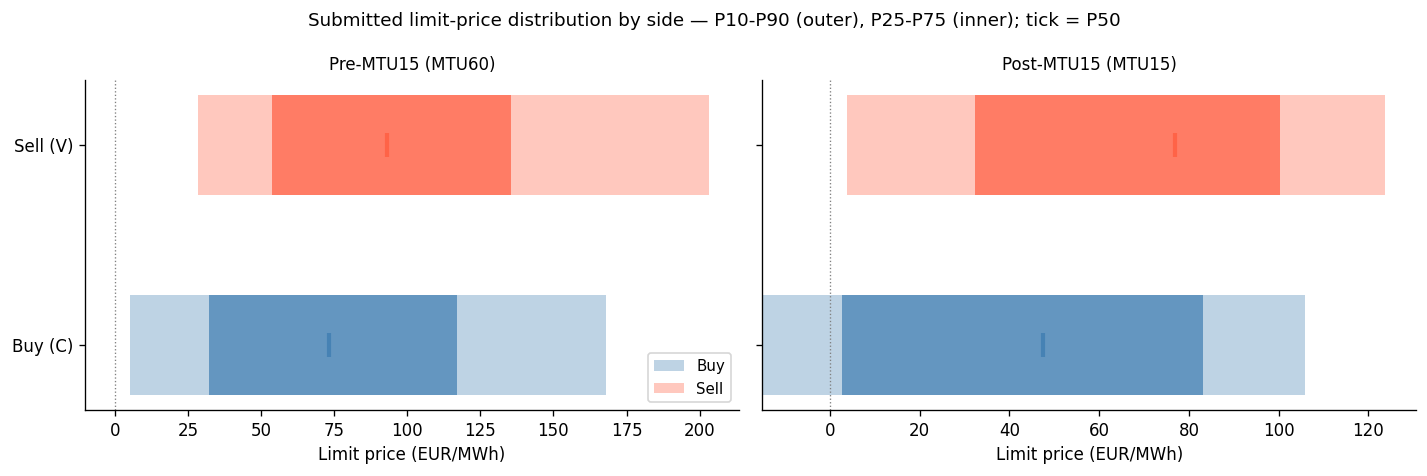

In [31]:
INTRADAY_REFORM_STR = INTRADAY_REFORM.date().isoformat()

price_dist = con_ord.execute(f"""
    SELECT
        offer_type,
        CASE WHEN trade_date < '{INTRADAY_REFORM_STR}' THEN 'Pre-MTU15 (MTU60)'
             ELSE 'Post-MTU15 (MTU15)' END                    AS regime,
        COUNT(*)                                               AS n_orders,
        ROUND(AVG(quantity_mw), 2)                            AS mean_mw,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.10), 2)       AS p10,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.25), 2)       AS p25,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.50), 2)       AS p50,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.75), 2)       AS p75,
        ROUND(APPROX_QUANTILE(price_eur_mwh, 0.90), 2)       AS p90
    FROM read_parquet('{ORDERS}')
    GROUP BY offer_type, regime
    ORDER BY regime, offer_type
""").df()

print("Submitted limit-price distribution (P10/P25/P50/P75/P90):")
print(price_dist.to_string(index=False))

# --- Plot: box-plot-style (P10-P90 outer bar, P25-P75 inner bar, P50 tick) ---
regimes_list  = ["Pre-MTU15 (MTU60)", "Post-MTU15 (MTU15)"]
sides         = [("C", "Buy", "steelblue"), ("V", "Sell", "tomato")]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for col_i, (regime, ax) in enumerate(zip(regimes_list, axes)):
    sub = price_dist[price_dist["regime"] == regime]
    for row_i, (side_code, side_label, color) in enumerate(sides):
        row = sub[sub["offer_type"] == side_code]
        if row.empty:
            continue
        row = row.iloc[0]
        ax.barh(row_i, row["p90"] - row["p10"], left=row["p10"],
                height=0.5, color=color, alpha=0.35, label=side_label if col_i == 0 else "")
        ax.barh(row_i, row["p75"] - row["p25"], left=row["p25"],
                height=0.5, color=color, alpha=0.75)
        ax.plot(row["p50"], row_i, marker="|", color=color, markersize=14, markeredgewidth=2.5)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Buy (C)", "Sell (V)"])
    ax.set_xlabel("Limit price (EUR/MWh)")
    ax.set_title(regime, fontsize=10)
    ax.axvline(0, color="grey", linewidth=0.8, linestyle=":")

axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle(
    "Submitted limit-price distribution by side — P10-P90 (outer), P25-P75 (inner); tick = P50",
    fontsize=11
)
plt.tight_layout()
plt.show()


### 8b. Execution-condition breakdown over time

OMIE supports several execution conditions $\kappa_o$:
- **GFD** (Good-for-Day): order rests in the book until matched, cancelled, or delivery closes
- **IOC** (Immediate-or-Cancel): executed immediately at the best available price, remainder cancelled
- **AON** (All-or-None): must be fully matched or rejected in full

The IOC share is a proxy for *immediacy preference* — participants seeking price discovery without sustained book exposure. A post-reform shift toward IOC would suggest that 15-min delivery granularity raises execution urgency.


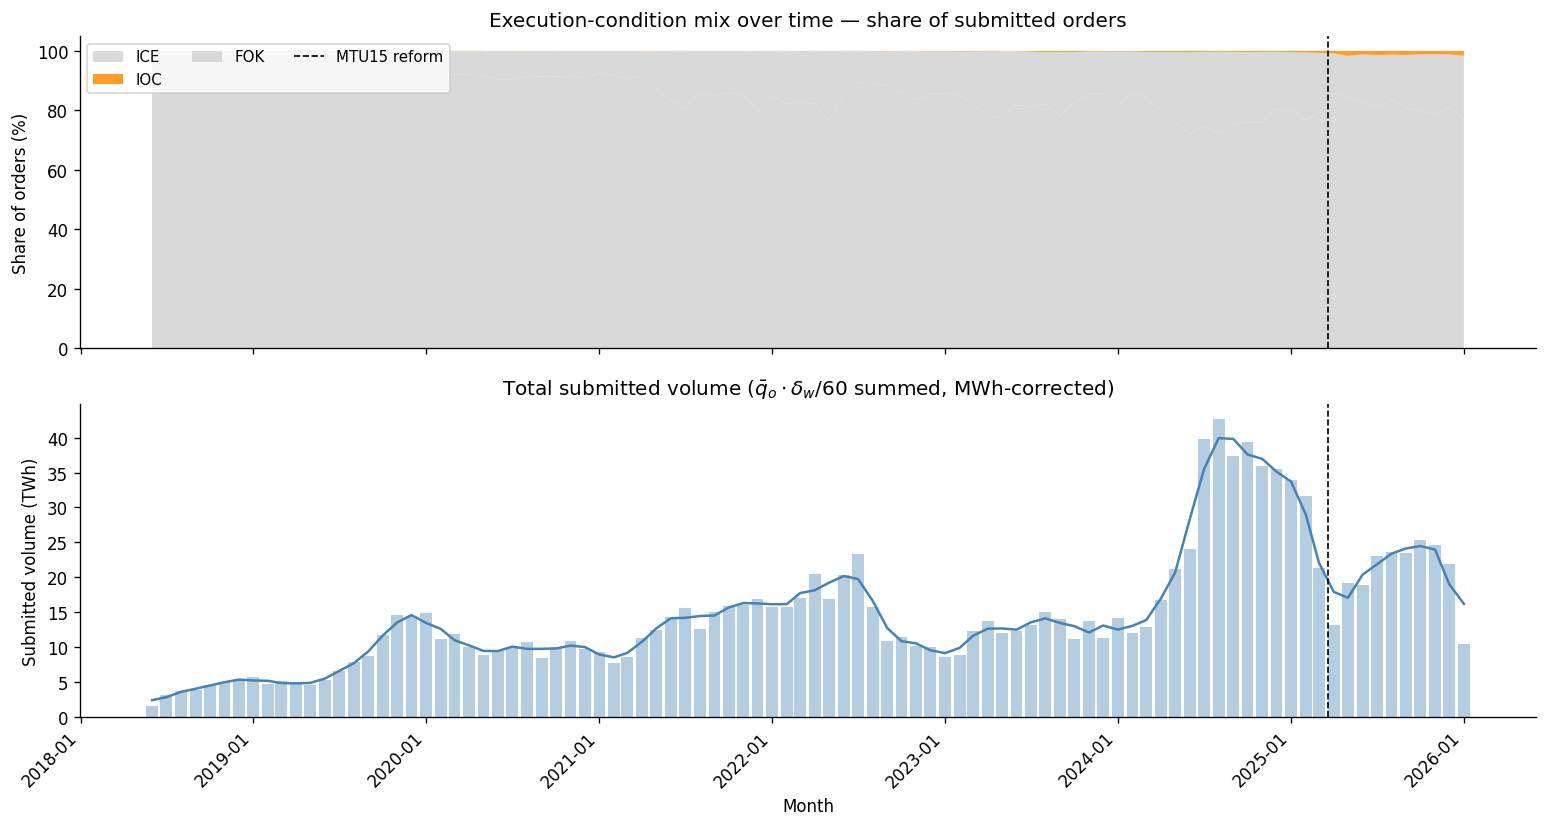

Mean IOC share by regime:
  Pre-MTU15  (<2025-03-19): 0.1%
  Post-MTU15 (>=2025-03-19): 1.3%


In [32]:
exec_monthly = con_ord.execute(f"""
    SELECT
        DATE_TRUNC('month', CAST(trade_date AS DATE))  AS month,
        exec_condition,
        COUNT(*)                                        AS n_orders,
        SUM(quantity_mw * mtu_minutes / 60.0)          AS total_mwh
    FROM read_parquet('{ORDERS}')
    GROUP BY month, exec_condition
    ORDER BY month, exec_condition
""").df()

exec_monthly["month"] = pd.to_datetime(exec_monthly["month"])

# Pivot to share per month
pivot_count = exec_monthly.pivot_table(
    index="month", columns="exec_condition", values="n_orders", aggfunc="sum"
).fillna(0)
pivot_share = pivot_count.div(pivot_count.sum(axis=1), axis=0) * 100

top_conds = pivot_share.sum().nlargest(5).index.tolist()
pivot_share = pivot_share[top_conds]

EXEC_COLORS = {
    "GFD": "steelblue", "IOC": "darkorange", "AON": "seagreen",
    "GTD": "orchid",    "GFS": "gray",
}

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].stackplot(
    pivot_share.index,
    [pivot_share[c] for c in top_conds],
    labels=top_conds,
    colors=[EXEC_COLORS.get(c, "lightgray") for c in top_conds],
    alpha=0.85,
)
axes[0].axvline(INTRADAY_REFORM, color="black", linestyle="--", linewidth=1, label="MTU15 reform")
axes[0].set_ylabel("Share of orders (%)")
axes[0].set_title("Execution-condition mix over time — share of submitted orders")
axes[0].legend(loc="upper left", fontsize=9, ncol=3)

monthly_total = exec_monthly.groupby("month")["total_mwh"].sum().reset_index()
monthly_total["smoothed"] = monthly_total["total_mwh"].rolling(3, center=True, min_periods=1).mean()
axes[1].bar(monthly_total["month"], monthly_total["total_mwh"] / 1e6,
            width=25, color="steelblue", alpha=0.4)
axes[1].plot(monthly_total["month"], monthly_total["smoothed"] / 1e6,
             color="steelblue", linewidth=1.5)
axes[1].axvline(INTRADAY_REFORM, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Submitted volume (TWh)")
axes[1].set_title(r"Total submitted volume ($\bar{q}_o \cdot \delta_w / 60$ summed, MWh-corrected)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Mean IOC share by regime:")
for regime_label, mask in [
    ("Pre-MTU15  (<2025-03-19)", pivot_share.index < INTRADAY_REFORM),
    ("Post-MTU15 (>=2025-03-19)", pivot_share.index >= INTRADAY_REFORM),
]:
    sub = pivot_share[mask]
    if "IOC" in sub.columns:
        print(f"  {regime_label}: {sub['IOC'].mean():.1f}%")


### 8c. Submitted prices vs. clearing price — cross-validation

A buy limit order at $\bar{p}_o^{\text{buy}}$ executes only against a sell order at $\bar{p}_o^{\text{sell}} \leq \bar{p}_o^{\text{buy}}$; clearing occurs at the passive (resting) order's price. Therefore:

$$\bar{p}_o^{\text{sell}} \leq p^*_{t,w} \leq \bar{p}_o^{\text{buy}} \quad \text{for each matched pair}$$

In aggregate, submitted sell orders form the ask side: orders at the P10 of the sell distribution are the most aggressively priced sellers. Similarly, buy orders near the P90 of the buy distribution are the most aggressive buyers. A consistency check is:

$$\underbrace{\tilde{p}^{\text{sell}}_{\text{P10}}}_{\text{aggressive ask}} \;\leq\; p^* \;\leq\; \underbrace{\tilde{p}^{\text{buy}}_{\text{P90}}}_{\text{aggressive bid}}$$

This is a weaker condition than full book consistency, but it verifies that the clearing price is reachable by submitted orders on both sides. Note that sell P50 > buy P50 is expected and represents the **book spread**: most submitted orders are not immediately crossing, so they rest in the book waiting for counterparts.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

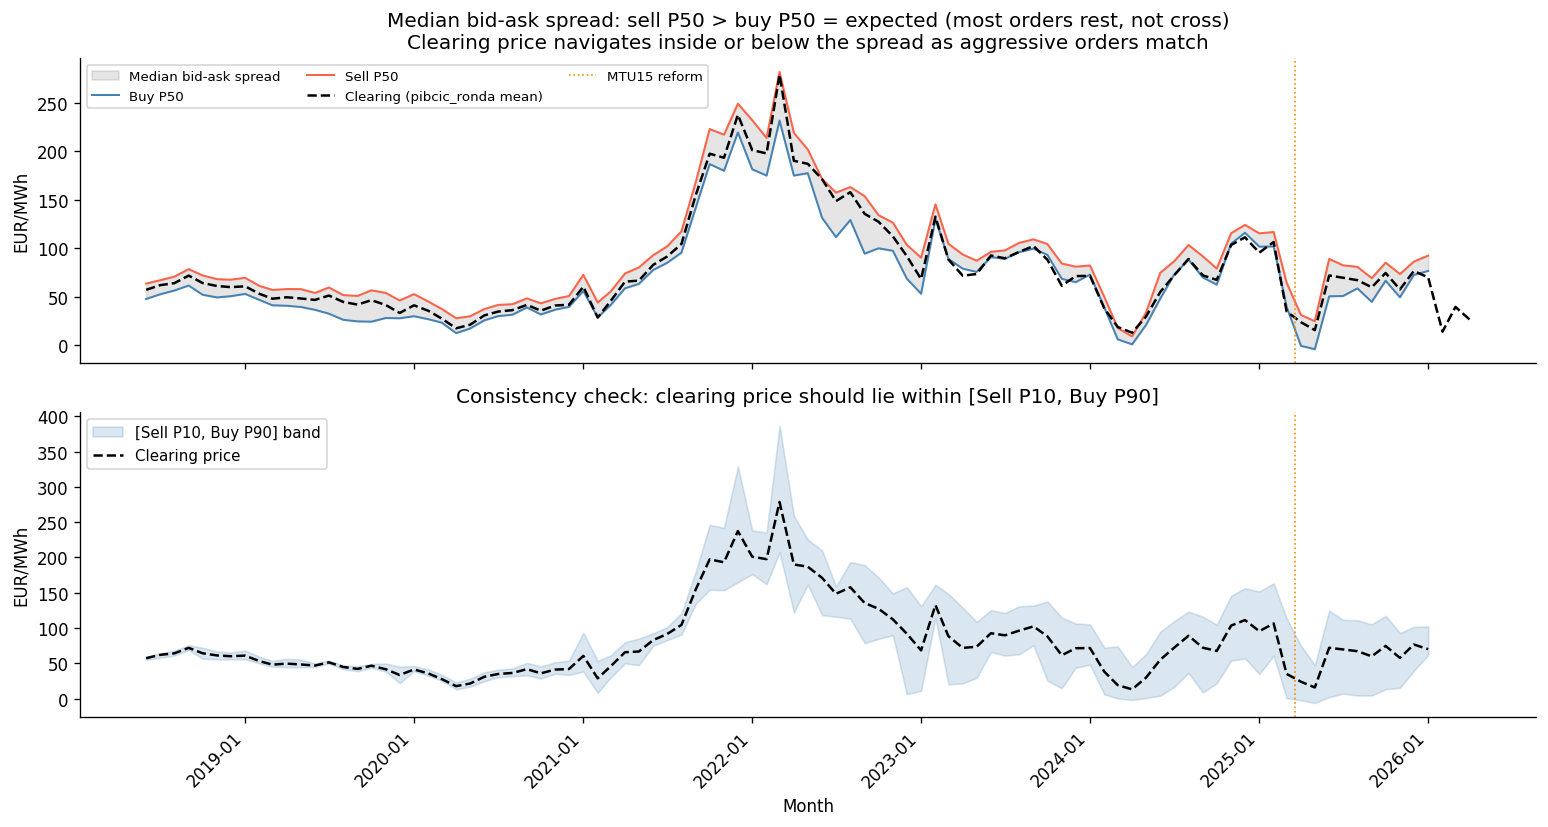

Months where clearing price lies inside [sell P10, buy P90]: 92 / 92
Mean book spread (sell P50 - buy P50): 20.83 EUR/MWh
Mean book spread pre-MTU15:  20.34 EUR/MWh
Mean book spread post-MTU15: 24.93 EUR/MWh


In [33]:
# Monthly P10 for sell orders, P90 for buy orders (aggressive side of each)
ord_monthly2 = con_ord.execute(f"""
    SELECT
        DATE_TRUNC('month', CAST(trade_date AS DATE))  AS month,
        offer_type,
        APPROX_QUANTILE(price_eur_mwh, 0.10)           AS p10,
        APPROX_QUANTILE(price_eur_mwh, 0.50)           AS p50,
        APPROX_QUANTILE(price_eur_mwh, 0.90)           AS p90
    FROM read_parquet('{ORDERS}')
    GROUP BY month, offer_type
    ORDER BY month, offer_type
""").df()
ord_monthly2["month"] = pd.to_datetime(ord_monthly2["month"])

buy_p50  = ord_monthly2[ord_monthly2["offer_type"] == "C"].set_index("month")["p50"]
buy_p90  = ord_monthly2[ord_monthly2["offer_type"] == "C"].set_index("month")["p90"]
sell_p50 = ord_monthly2[ord_monthly2["offer_type"] == "V"].set_index("month")["p50"]
sell_p10 = ord_monthly2[ord_monthly2["offer_type"] == "V"].set_index("month")["p10"]

# Clearing price from precios_pibcic_ronda (already loaded)
clearing_monthly = (
    period_price.groupby(period_price["date"].dt.to_period("M"))["price_mean_es_eur_mwh"]
    .mean()
    .reset_index()
)
clearing_monthly["month"] = clearing_monthly["date"].dt.to_timestamp()
clearing_monthly = clearing_monthly.set_index("month")["price_mean_es_eur_mwh"]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: bid-ask spread at the median level (sell P50 - buy P50)
common = sell_p50.index.intersection(buy_p50.index)
spread = sell_p50[common] - buy_p50[common]
axes[0].fill_between(common, buy_p50[common], sell_p50[common],
                     alpha=0.2, color="gray", label="Median bid-ask spread")
axes[0].plot(buy_p50.index,  buy_p50.values,  color="steelblue", linewidth=1.2, label="Buy P50")
axes[0].plot(sell_p50.index, sell_p50.values, color="tomato",    linewidth=1.2, label="Sell P50")
axes[0].plot(clearing_monthly.index, clearing_monthly.values,
             color="black", linewidth=1.5, linestyle="--", label="Clearing (pibcic_ronda mean)")
axes[0].axvline(INTRADAY_REFORM, color="darkorange", linestyle=":", linewidth=1, label="MTU15 reform")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title(
    "Median bid-ask spread: sell P50 > buy P50 = expected (most orders rest, not cross)\n"
    "Clearing price navigates inside or below the spread as aggressive orders match"
)
axes[0].legend(fontsize=8, ncol=3)

# Bottom: consistency check — clearing in [sell P10, buy P90]
common2 = sell_p10.index.intersection(buy_p90.index).intersection(clearing_monthly.index)
axes[1].fill_between(common2, sell_p10[common2], buy_p90[common2],
                     alpha=0.2, color="steelblue", label="[Sell P10, Buy P90] band")
axes[1].plot(clearing_monthly[common2].index, clearing_monthly[common2].values,
             color="black", linewidth=1.5, linestyle="--", label="Clearing price")
axes[1].axvline(INTRADAY_REFORM, color="darkorange", linestyle=":", linewidth=1)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("EUR/MWh")
axes[1].set_title("Consistency check: clearing price should lie within [Sell P10, Buy P90]")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

n_inside = (
    (clearing_monthly[common2] >= sell_p10[common2]) &
    (clearing_monthly[common2] <= buy_p90[common2])
).sum()
print(f"Months where clearing price lies inside [sell P10, buy P90]: {n_inside} / {len(common2)}")
print(f"Mean book spread (sell P50 - buy P50): {spread.mean():.2f} EUR/MWh")
print(f"Mean book spread pre-MTU15:  {spread[spread.index < INTRADAY_REFORM].mean():.2f} EUR/MWh")
print(f"Mean book spread post-MTU15: {spread[spread.index >= INTRADAY_REFORM].mean():.2f} EUR/MWh")
